# OpenBCI Ganglion 실습 1 · 근전도(EMG) 신호 다루기

**재활재생개론 · 근육이 내는 전기 신호를 측정하고 처리하기**

---

## 이 실습에서 하는 일

| 단계 | 내용 |
| --- | --- |
| 1 | BLED112 동글로 Ganglion 보드에 연결 |
| 2 | 팔 근육의 **근전도(EMG)** 신호 수집 |
| 3 | 필터링 — 잡음 제거 |
| 4 | RMS · 주파수 분석 |
| 5 | 그래프로 확인하고 CSV로 저장 |

## 준비물

- **OpenBCI Ganglion 보드** (전원 ON)
- **BLED112 USB 동글** (COM 포트에 연결)
- **EMG 전극** — 팔뚝에 붙일 것

## 근전도(EMG)란

근육이 수축할 때 근섬유에서 발생하는 **전기 신호**입니다.
피부에 전극을 붙이면 그 아래 근육의 활동을 전압으로 읽을 수 있습니다.

| | 값 |
| --- | --- |
| 진폭 | 수십 µV ~ 수 mV (뇌파보다 훨씬 큼) |
| 주요 주파수 | 20 ~ 450 Hz (에너지는 50~150 Hz 부근에 집중) |
| 특징 | 힘을 줄수록 진폭이 커진다 |


## Ganglion 보드 사양

| 항목 | 값 |
| --- | --- |
| 채널 수 | **4개** |
| 샘플링 레이트 | **200 Hz** |
| 볼 수 있는 최대 주파수 | **100 Hz** (= 200 ÷ 2, 나이퀴스트) |
| 통신 | BLE (BLED112 동글 경유) |

---
**위에서 아래로 셀을 하나씩 실행하세요.** (`Shift + Enter`)

---
# 1단계 · Board 연결
## 1-1. 라이브러리 준비

필요한 도구를 불러옵니다.

**BrainFlow**는 OpenBCI 공식 라이브러리로, OpenBCI GUI도 내부적으로 이것을 사용합니다.
우리가 직접 통신 프로토콜을 구현할 필요 없이 보드와 대화할 수 있게 해 줍니다.

> 처음 실행한다면 아래 셀이 자동으로 `brainflow`를 설치합니다 (1~2분).

In [1]:
import sys
import subprocess
import warnings
from importlib.metadata import version as _pkg_version, PackageNotFoundError

# 콘솔에서 한글과 µ 기호가 깨지지 않도록 (Windows cp949 대응)
try:
    sys.stdout.reconfigure(encoding='utf-8')
except Exception:
    pass

warnings.filterwarnings('ignore', message='pkg_resources is deprecated')

# ─────────────────────────────────────────────────────────────
# brainflow 는 반드시 5.20.0 이어야 한다.
#
# 최신 brainflow(5.21+)는 BLED112 동글 지원이 죽어 있어서
# 연결 시도가 0초 만에 실패한다.
#
# 주의: 디스크의 버전이 맞아도, 커널이 예전 버전을 메모리에 들고 있으면
#       여전히 실패한다. 그래서 실제 로드된 DLL 버전까지 확인한다.
# ─────────────────────────────────────────────────────────────
REQUIRED_BF = '5.20.0'
_need_restart = False

try:
    _disk_bf = _pkg_version('brainflow')
except PackageNotFoundError:
    _disk_bf = None

# (1) 디스크에 설치된 버전이 다르면 맞춰 설치
if _disk_bf != REQUIRED_BF:
    print(f'brainflow 버전 조정: {_disk_bf} -> {REQUIRED_BF}')
    print('1~2분 걸립니다...')
    _cmd = [sys.executable, '-m', 'pip', 'install', '-q', f'brainflow=={REQUIRED_BF}']
    try:
        import pkg_resources          # 5.20.0 이 이걸 사용한다
    except ImportError:
        _cmd.append('setuptools<81')  # 없을 때만 함께 설치
    subprocess.check_call(_cmd)
    print('설치 완료')
    if 'brainflow' in sys.modules:
        _need_restart = True

# (2) 이미 메모리에 올라온 DLL 이 다른 버전인지 확인
if 'brainflow' in sys.modules and not _need_restart:
    try:
        from brainflow.board_shim import BoardShim as _BS
        if _BS.get_version() != REQUIRED_BF:
            _need_restart = True
    except Exception:
        _need_restart = True

if _need_restart:
    print()
    print('!' * 62)
    print('  커널을 재시작해야 합니다.')
    print()
    print('  메모리에 예전 버전이 남아 있어서, 이대로 진행하면')
    print('  연결이 0초 만에 실패합니다.')
    print()
    print('    메뉴에서  Kernel > Restart Kernel  실행')
    print('    그 다음 이 셀부터 다시 실행하세요.')
    print('!' * 62)
    raise SystemExit

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
from scipy import signal as sp_signal

from brainflow.board_shim import BoardShim, BrainFlowInputParams, BoardIds

# 그래프 한글 표시 - 설치된 한글 폰트 중 먼저 발견되는 것을 사용
from matplotlib import font_manager
_installed_fonts = {f.name for f in font_manager.fontManager.ttflist}
_korean_font = '(없음)'
for _cand in ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'Noto Sans KR', 'Gulim']:
    if _cand in _installed_fonts:
        plt.rcParams['font.family'] = _cand
        _korean_font = _cand
        break
plt.rcParams['axes.unicode_minus'] = False   # 음수 부호가 네모로 깨지는 것 방지

_loaded_bf = BoardShim.get_version()

print('준비 완료')
print(f'  Python    : {sys.version.split()[0]}')
print(f'  BrainFlow : {_loaded_bf}   (실제 로드된 버전)')
print(f'  NumPy     : {np.__version__}')
print(f'  SciPy     : {__import__("scipy").__version__}')
print(f'  한글 폰트 : {_korean_font}')

if _loaded_bf != REQUIRED_BF:
    print()
    print(f'경고: BrainFlow 가 {REQUIRED_BF} 이 아닙니다. 연결이 실패할 것입니다.')
    print('     Kernel > Restart Kernel 후 이 셀부터 다시 실행하세요.')

준비 완료
  Python    : 3.12.4
  BrainFlow : 5.20.0   (실제 로드된 버전)
  NumPy     : 1.26.4
  SciPy     : 1.13.1
  한글 폰트 : Malgun Gothic


---
## 1-2. 단계 · 동글이 꽂힌 COM 포트 찾기

BLED112 동글은 컴퓨터에 **가상 시리얼 포트**(COM3, COM4 …)로 나타납니다.
OpenBCI GUI에서 선택했던 것과 **같은 포트 번호**를 쓰면 됩니다.

아래 셀이 후보를 찾아 줍니다. 

In [2]:
try:
    from serial.tools import list_ports
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'pyserial'])
    from serial.tools import list_ports

ports = list(list_ports.comports())

print('연결된 COM 포트')
print('=' * 60)

if not ports:
    print('포트를 찾지 못했습니다.')
    print('  -> BLED112 동글이 USB 에 꽂혀 있는지 확인하세요.')
else:
    for p in ports:
        # 동글일 가능성이 높은 포트에 표시
        desc = (p.description or '').lower()
        hint = '  <-- 동글일 가능성 높음' if ('bluetooth' in desc or 'cp210' in desc) else ''
        print(f'  {p.device:<8} {p.description}{hint}')

print('=' * 60)
print('위 목록에서 동글의 포트 번호를 확인하고, 다음 셀에 적으세요.')

연결된 COM 포트
  COM3     표준 Bluetooth에서 직렬 링크(COM3)  <-- 동글일 가능성 높음
  COM4     표준 Bluetooth에서 직렬 링크(COM4)  <-- 동글일 가능성 높음
  COM5     USB 직렬 장치(COM5)
위 목록에서 동글의 포트 번호를 확인하고, 다음 셀에 적으세요.


---
## 1-3. 단계 · Bluetooth 연결 설정 

### `BOARD_MAC` — 어떤 Ganglion 보드에 연결할지 지정

| 상황 | 설정값 |
| --- | --- |
| 주변에 Ganglion이 **내 것 하나뿐** | `''` (빈 문자열) → 자동으로 찾음 |

> ⚠️ 여러 보드가 동시에 켜져 있는데 비워 두면 **옆 사람 보드에 연결될 수 있습니다.**

### `DURATION_SEC`
몇 초 동안 신호를 모을지. 처음에는 10초를 권장합니다.

In [3]:
# ===================== 학생 설정 구역 =====================

COM_PORT     = 'COM5'      # 동글 포트, 각자 환경에 맞게 수정

BOARD_MAC    = ''          # 비워 두세요.
                           # BLED112 동글 방식은 MAC 을 지정해도 무시됩니다.
                           # 여러 보드 대처법은 아래 스캔 셀 설명 참고

DURATION_SEC = 10          # 수집 시간 (초)

# ==========================================================

BOARD_ID = BoardIds.GANGLION_BOARD   # BLED112 동글용 Ganglion (board_id = 1)

print('설정 확인')
print('=' * 60)
print(f'  동글 포트   : {COM_PORT}')
print(f'  대상 보드   : 「내 보드 확인」 셀에서 결정')
print(f'  수집 시간   : {DURATION_SEC} 초')
print('=' * 60)

print()
print('다음 단계로 진행하기 전에 「내 보드 확인」 셀을 반드시 실행하세요.')
print('켜져 있는 Ganglion 이 1대일 때만 연결이 허용됩니다.')

설정 확인
  동글 포트   : COM5
  대상 보드   : 「내 보드 확인」 셀에서 결정
  수집 시간   : 10 초

다음 단계로 진행하기 전에 「내 보드 확인」 셀을 반드시 실행하세요.
켜져 있는 Ganglion 이 1대일 때만 연결이 허용됩니다.


---
## 1-4. 보드 사양 확인 (연결 없이)

BrainFlow는 보드에 연결하지 않아도 사양을 알려줍니다.
**내가 다루는 신호가 몇 채널이고 초당 몇 개인지** 먼저 확인

이 값들은 뒤의 모든 분석(필터 설계, 주파수 축)의 기준이 됩니다.

> `get_eeg_channels()` 라는 이름이지만, BrainFlow 가 생체전위 채널을
> 통칭하는 표현입니다. **우리는 이 채널들을 EMG 측정에 씁니다.**

In [4]:
FS          = BoardShim.get_sampling_rate(BOARD_ID)   # 샘플링 레이트 (Hz)
EMG_CHANNELS = BoardShim.get_emg_channels(BOARD_ID)  # EMG 채널
N_CH        = len(EMG_CHANNELS)
NYQUIST     = FS / 2

print('Ganglion 보드 사양')
print('=' * 60)
print(f'  board_id            : {int(BOARD_ID)}')
print(f'  샘플링 레이트       : {FS} Hz')
print(f'  채널 수             : {N_CH} 개')
print(f'  채널 행 인덱스      : {EMG_CHANNELS}')
print(f'  볼 수 있는 최대 주파수 : {NYQUIST:.0f} Hz  (나이퀴스트 = {FS}/2)')
print('=' * 60)
print()
print(f'{DURATION_SEC}초 수집하면 채널당 약 {FS * DURATION_SEC}개의 샘플이 모입니다.')
print()
print('참고: BrainFlow 는 데이터를 (행=채널, 열=시간) 행렬로 줍니다.')
print('      채널 행 인덱스는 그 행렬에서 신호가 들어있는 줄 번호입니다.')

Ganglion 보드 사양
  board_id            : 1
  샘플링 레이트       : 200 Hz
  채널 수             : 4 개
  채널 행 인덱스      : [1, 2, 3, 4]
  볼 수 있는 최대 주파수 : 100 Hz  (나이퀴스트 = 200/2)

10초 수집하면 채널당 약 2000개의 샘플이 모입니다.

참고: BrainFlow 는 데이터를 (행=채널, 열=시간) 행렬로 줍니다.
      채널 행 인덱스는 그 행렬에서 신호가 들어있는 줄 번호입니다.


---
# 🚦 내 보드 확인 · **연결 전 필수**

강의실처럼 Ganglion 이 여러 대 있을 때 **엉뚱한 보드에 연결되는 것을 막는 단계**입니다.

연결된 보드는 광고를 멈추므로, 다음 학생에게 잡히지 않습니다.
따라서 **각자 자기 보드에 정확히 연결**됩니다.

> ⚠️ 이 셀은 동글을 직접 사용합니다. **보드에 연결되지 않은 상태**에서 실행하세요.
> 이미 연결했다면 마지막 단계로 해제한 뒤 실행하세요.

In [5]:
import serial

def scan_ganglions(port, duration=8.0):
    """BLED112 동글로 주변 Ganglion 을 스캔한다.

    동글에 BGAPI(Bluegiga API) 명령을 직접 보내 광고 패킷을 읽는다.
    BrainFlow 는 발견한 장치를 알려주지 않기 때문에 직접 확인해야 한다.
    """
    def pkt(method, payload=b''):
        return bytes([0x00, len(payload), 0x06, method]) + payload   # class 0x06 = GAP

    def parse_name(data):
        i = 0
        while i < len(data):
            ln = data[i]
            if ln == 0:
                break
            if i + 1 < len(data) and data[i + 1] in (0x08, 0x09):   # 단축/완전 이름
                nm = data[i + 2:i + 1 + ln].decode('utf-8', errors='ignore')
                nm = nm.strip('\x00').strip()
                return nm or None
            i += ln + 1
        return None

    found = {}
    with serial.Serial(port, 115200, timeout=0.2) as ser:
        ser.write(pkt(0x04)); time.sleep(0.2); ser.reset_input_buffer()
        ser.write(pkt(0x07, bytes([0x4B, 0x00, 0x32, 0x00, 0x01])))   # 스캔 파라미터
        time.sleep(0.2); ser.reset_input_buffer()
        ser.write(pkt(0x02, bytes([0x02])))                           # 스캔 시작

        buf = bytearray()
        t_end = time.time() + duration
        while time.time() < t_end:
            ch = ser.read(256)
            if ch:
                buf.extend(ch)
            while len(buf) >= 4:
                plen = ((buf[0] & 0x07) << 8) | buf[1]
                total = 4 + plen
                if len(buf) < total:
                    break
                p = bytes(buf[:total]); del buf[:total]
                if (p[0] & 0x80) and p[2] == 0x06 and p[3] == 0x00 and plen >= 11:
                    b = p[4:]
                    rssi = b[0] - 256 if b[0] > 127 else b[0]
                    mac = ':'.join(f'{x:02x}' for x in reversed(b[2:8]))
                    nm = parse_name(b[11:11 + b[10]])
                    e = found.setdefault(mac, {'name': None, 'rssi': -999})
                    if nm:
                        e['name'] = nm
                    e['rssi'] = max(e['rssi'], rssi)

        ser.write(pkt(0x04)); time.sleep(0.3)      # 스캔 종료
        ser.reset_input_buffer()

    return {m: i for m, i in found.items()
            if i['name'] and 'ganglion' in i['name'].lower()}


# ─────────────────────────────────────────────────────────
print(f'{COM_PORT} 주변을 8초간 확인합니다...')

try:
    ganglions = scan_ganglions(COM_PORT, 8.0)
except serial.SerialException as e:
    SAFE_TO_CONNECT = False
    TARGET_BOARD = TARGET_MAC = TARGET_RSSI = None
    print()
    print('=' * 66)
    print(f'{COM_PORT} 를 열 수 없습니다 - 다른 프로그램이 쓰고 있습니다')
    print('=' * 66)
    print(f'  ({e})')
    print()

    # 지금 떠 있는 다른 커널을 찾아서 보여준다
    try:
        import os
        import subprocess
        me = os.getpid()
        ps = subprocess.run(
            ['powershell', '-NoProfile', '-Command',
             "Get-CimInstance Win32_Process -Filter \"Name like '%python%' or Name like '%javaw%'\" "
             "| ForEach-Object { \"$($_.ProcessId)|$($_.Name)|"
             "$($_.CreationDate.ToString('HH:mm:ss'))|$($_.CommandLine)\" }"],
            capture_output=True, text=True, timeout=20)
        rows = []
        for line in ps.stdout.strip().splitlines():
            parts = line.split('|', 3)
            if len(parts) < 4:
                continue
            pid, pname, started, cmd = parts
            pid = int(pid)
            if pid == me:
                continue
            if 'ipykernel_launcher' in cmd:
                kind = '노트북 커널'
            elif 'javaw' in pname.lower():
                kind = 'OpenBCI GUI 로 추정'
            else:
                continue
            rows.append((pid, started, kind))
        if rows:
            print('  지금 떠 있는 다른 프로세스 (이 중 하나가 포트를 잡고 있습니다)')
            print('  ' + '-' * 60)
            for pid, started, kind in sorted(rows, key=lambda r: r[1]):
                print(f'    PID {pid:<8} {started}   {kind}')
            print('  ' + '-' * 60)
            print(f'  (지금 이 커널은 PID {me} 입니다)')
            print()
    except Exception:
        pass

    print('  해결 방법')
    print()
    print('  [VS Code 를 쓰는 경우]')
    print('    - 열어 둔 다른 노트북 탭으로 가서 우측 상단 커널 -> Restart Kernel')
    print('    - 또는 그 노트북 탭을 완전히 닫기')
    print()
    print('  [브라우저 Jupyter 를 쓰는 경우]')
    print('    - Running(실행 중) 목록에서 예전 커널을 Shutdown')
    print()
    print('  [그 밖에]')
    print('    - OpenBCI GUI: 창만 닫지 말고 작업관리자에서 javaw 까지 종료')
    print('    - 이 노트북에서 이미 연결했다면: 마지막 단계(연결 해제) 실행')
    print('    - 위 PID 를 직접 종료:  Stop-Process -Id <번호>   (PowerShell)')
    raise SystemExit

print()
print('=' * 62)

if len(ganglions) == 0:
    SAFE_TO_CONNECT = False
    TARGET_BOARD = TARGET_MAC = TARGET_RSSI = None
    print('켜져 있는 Ganglion 이 없습니다')
    print('=' * 62)
    print('  1. 보드 전원 스위치 ON (파란 LED 깜빡임)')
    print('  2. 배터리 확인')
    print('  3. 이미 연결 중이면 마지막 단계로 해제 후 다시 실행')

elif len(ganglions) == 1:
    SAFE_TO_CONNECT = True
    _mac, _info = next(iter(ganglions.items()))
    TARGET_BOARD = _info['name']     # 광고명 (BLE advertised name)
    TARGET_MAC   = _mac              # MAC 주소
    TARGET_RSSI  = _info['rssi']     # 신호 세기 (dBm)
    print('Ganglion 1대 - 안전하게 연결할 수 있습니다')
    print('=' * 62)
    print(f'  {_info["name"]}   {_mac}   신호 {_info["rssi"]} dBm')
    print()
    print('  다음 셀에서 연결하면 반드시 이 보드에 연결됩니다.')

else:
    SAFE_TO_CONNECT = False
    TARGET_BOARD = TARGET_MAC = TARGET_RSSI = None
    print(f'경고 - Ganglion 이 {len(ganglions)}대 켜져 있습니다')
    print('=' * 62)
    for _m, _i in sorted(ganglions.items(), key=lambda x: -x[1]['rssi']):
        print(f'  {_i["name"]:<20} {_m}   신호 {_i["rssi"]:4d} dBm')
    print()
    print('  이대로 연결하면 어느 보드에 붙을지 알 수 없습니다.')
    print('  BLED112 방식은 MAC 을 지정해도 선택되지 않습니다.')
    print()
    print('  해결: 내 보드만 남기고 나머지 전원을 끈 뒤 이 셀을 다시 실행하세요.')

COM5 주변을 8초간 확인합니다...

Ganglion 1대 - 안전하게 연결할 수 있습니다
  Ganglion-c57c   c5:cf:b4:83:e8:c6   신호 -38 dBm

  다음 셀에서 연결하면 반드시 이 보드에 연결됩니다.


---
## 1-5단계 · 보드 연결

`BrainFlowInputParams` 에 접속 정보를 담아 보드를 엽니다.

- `serial_port` → 동글이 꽂힌 COM 포트 (**필수**)
- `mac_address` → 연결할 보드 지정 (**선택**, 비우면 자동 탐색)
- `timeout` → 몇 초까지 기다릴지

`prepare_session()` 이 성공하면 연결된 것입니다. 보드 LED가 바뀌는 것도 확인해 보세요.

In [6]:
# 안전 게이트를 통과했는지 확인
if not globals().get('SAFE_TO_CONNECT', False):
    raise SystemExit(
        '\n중단: 앞의 「내 보드 확인」 셀을 먼저 통과하세요.\n'
        '      켜져 있는 Ganglion 이 1대일 때만 연결이 허용됩니다.\n'
        '      (내 보드 외에는 전원을 꺼 주세요)')

print(f'대상 보드: {TARGET_BOARD}')
print()

BoardShim.disable_board_logger()   # 상세 로그를 보려면 5-A 진단 셀 사용

params = BrainFlowInputParams()
params.serial_port = COM_PORT
params.mac_address = BOARD_MAC     # 빈 문자열이면 자동 탐색
params.timeout     = 40            # 초. 첫 탐색은 오래 걸릴 수 있다

board     = BoardShim(BOARD_ID, params)
connected = False

# 첫 시도는 실패하고 두 번째에 붙는 경우가 흔하다. 자동으로 3번까지 재시도한다.
MAX_TRY = 3

print(f'{COM_PORT} 를 통해 Ganglion 연결 시도 중...')
print('보드 전원이 켜져 있는지 확인하세요.')
print('첫 시도는 40초까지 걸릴 수 있습니다. 기다려 주세요.')
print()

for attempt in range(1, MAX_TRY + 1):
    t_start = time.time()
    try:
        board.prepare_session()
        connected = True
        print(f'[{attempt}/{MAX_TRY}] 연결 성공  ({time.time() - t_start:.1f}초)')
        break
    except Exception as e:
        print(f'[{attempt}/{MAX_TRY}] 실패 ({time.time() - t_start:.1f}초): {e}')
        try:
            board.release_session()
        except Exception:
            pass
        if attempt < MAX_TRY:
            print('        잠시 후 다시 시도합니다...')
            time.sleep(3)

print()
if connected:
    # 연결된 보드 정보
    # 게이트에서 광고 중인 보드가 1대임을 확인했으므로, 그 보드가 곧 연결된 보드다.
    CONNECTED_BOARD = {
        'name': TARGET_BOARD,      # 광고명 (BLE advertised name)
        'mac':  TARGET_MAC,        # MAC 주소
        'rssi': TARGET_RSSI,       # 신호 세기 (dBm)
    }
    print('=' * 56)
    print('연결된 보드')
    print('=' * 56)
    print(f'  광고명 (advertised name) : {CONNECTED_BOARD["name"]}')
    print(f'  MAC 주소                 : {CONNECTED_BOARD["mac"]}')
    print(f'  신호 세기                : {CONNECTED_BOARD["rssi"]} dBm')
    print('=' * 56)
    print()
    print('6단계로 진행하세요.')
else:
    print('=' * 60)
    print(f'{MAX_TRY}번 모두 실패했습니다. 아래를 확인하세요.')
    print('=' * 60)
    print('  1. OpenBCI GUI 를 완전히 종료했나요?  (가장 흔한 원인)')
    print('     - 창만 닫지 말고 작업관리자에서 javaw 프로세스까지 확인')
    print('  2. 보드 전원 스위치가 ON 인가요?')
    print('  3. 배터리가 충분한가요?')
    print('  4. COM_PORT 번호가 맞나요?  (2단계 결과와 대조)')
    print('  5. 동글을 뽑았다 다시 꽂고 커널 재시작')
    print()
    print('  그래도 안 되면 아래 5-A 진단 셀을 실행해 로그를 확인하세요.')

대상 보드: Ganglion-c57c

COM5 를 통해 Ganglion 연결 시도 중...
보드 전원이 켜져 있는지 확인하세요.
첫 시도는 40초까지 걸릴 수 있습니다. 기다려 주세요.

[1/3] 연결 성공  (1.4초)

연결된 보드
  광고명 (advertised name) : Ganglion-c57c
  MAC 주소                 : c5:cf:b4:83:e8:c6
  신호 세기                : -38 dBm

6단계로 진행하세요.


---
### 1-5-A. 연결이 안 될 때 (진단)

5단계가 실패했을 때만 실행하세요. 성공했다면 **건너뛰고 6단계로** 가면 됩니다.

BrainFlow 의 내부 로그를 켜서 **어디에서 막혔는지** 확인합니다.

로그를 읽는 법 — **실패까지 걸린 시간**이 핵심 단서입니다.

| 소요 시간 | 의미 | 확인할 것 |
| --- | --- | --- |
| **0초** | 스캔조차 못 함 | brainflow 5.20.0 인지, 커널 재시작했는지, COM 포트 |
| **타임아웃까지** | 스캔했으나 못 찾음 | 보드 전원, 배터리, GUI 종료 |

`detected firmware version 0` 이 보이면 보드를 발견하지 못했다는 뜻입니다.

**실행 전 체크**
1. OpenBCI GUI 완전 종료
2. Ganglion 전원 ON, 파란 LED 깜빡임 확인
3. 커널 재시작 (이전 연결이 동글을 잡고 있을 수 있음)

In [8]:
# ============ 연결 진단 ============
# BrainFlow 내부 로그를 파일로 받아 어디서 막혔는지 확인한다.

LOG_PATH = Path('brainflow_debug.log')

BoardShim.set_log_file(str(LOG_PATH))
BoardShim.enable_dev_board_logger()      # 상세 로그 켜기

diag_params = BrainFlowInputParams()
diag_params.serial_port = COM_PORT
diag_params.mac_address = BOARD_MAC
diag_params.timeout     = 25

diag_board = BoardShim(BOARD_ID, diag_params)

print(f'{COM_PORT} 로 진단 시도 중... 최대 25초 걸립니다.')
print()

t_diag = time.time()
try:
    diag_board.prepare_session()
    print(f'>>> 연결 성공 ({time.time()-t_diag:.1f}초). 5단계로 돌아가 진행하세요.')
    diag_board.release_session()
except Exception as e:
    elapsed = time.time() - t_diag
    print(f'>>> 실패 ({elapsed:.1f}초): {e}')
    print()
    print('=' * 62)
    print('소요 시간으로 원인 좁히기')
    print('=' * 62)
    if elapsed < 2:
        print('  0초에 가깝게 실패했습니다 -> 라이브러리 / 포트 문제')
        print('    1. brainflow 가 5.20.0 인가?  (1단계 출력 확인)')
        print('    2. 커널을 재시작했는가?  (Kernel > Restart Kernel)')
        print('    3. COM_PORT 번호가 맞는가?  (2단계 결과와 대조)')
    else:
        print('  끝까지 기다린 뒤 실패했습니다 -> 스캔은 했으나 보드를 못 찾음')
        print('    1. 보드 전원 스위치 ON (파란 LED 깜빡임)')
        print('    2. 배터리 충전 상태')
        print('    3. OpenBCI GUI 종료')
        print('    4. BOARD_MAC 을 지정했다면, 값이 맞는지 확인')
        print('       (위의 "내 보드 찾기" 셀로 MAC 을 다시 확인하세요)')

BoardShim.disable_board_logger()

log_text = LOG_PATH.read_text(encoding='utf-8', errors='replace') if LOG_PATH.exists() else ''

print()
print('=' * 62)
print('BrainFlow 로그 (마지막 20줄)')
print('=' * 62)
for line in log_text.strip().splitlines()[-20:]:
    if 'incoming json' in line or line.strip().startswith(('"', '{', '}')):
        continue
    print(' ', line)

COM5 로 진단 시도 중... 최대 25초 걸립니다.

>>> 실패 (0.0초): ANOTHER_BOARD_IS_CREATED_ERROR:16 unable to prepare streaming session

소요 시간으로 원인 좁히기
  0초에 가깝게 실패했습니다 -> 라이브러리 / 포트 문제
    1. brainflow 가 5.20.0 인가?  (1단계 출력 확인)
    2. 커널을 재시작했는가?  (Kernel > Restart Kernel)
    3. COM_PORT 번호가 맞는가?  (2단계 결과와 대조)

BrainFlow 로그 (마지막 20줄)
  [2026-07-25 20:17:06.608] [board_logger] [debug] use dyn lib: C:\Users\Owner\anaconda3\Lib\site-packages\brainflow\lib\GanglionLib.dll
  [2026-07-25 20:17:06.608] [board_logger] [trace] Board object created 1
  [2026-07-25 20:17:06.608] [board_logger] [info] only one ganglion per process is supported


---
### 1-5-B. 전극 임피던스 점검

**신호를 모으기 전에 전극이 잘 붙었는지 숫자로 확인합니다.**

### 임피던스가 왜 중요한가

임피던스는 **전극과 피부 사이가 전기적으로 얼마나 잘 통하는지**를 나타냅니다.
값이 크면 접촉이 나쁘다는 뜻이고, 그러면

- 신호가 작고 잡음이 크다
- 60 Hz 전원 잡음을 더 많이 주워 온다
- 채널마다 신호 크기가 제각각이 되어 **2차시 분류 정확도가 떨어진다**

파형만 봐서는 "좀 지저분한데?" 정도로만 알 수 있지만,
임피던스는 **어느 전극이 문제인지 콕 집어** 줍니다.

### 어떻게 재는가

Ganglion 보드가 전극에 아주 약한 교류 전류를 흘리고,
그때 생기는 전압으로 임피던스를 계산합니다.
`config_board('z')` 로 시작하고 `config_board('Z')` 로 끝냅니다.

측정 대상은 **4개 채널 전극 + 기준(REF) 전극**, 총 5개입니다.

> 임피던스 모드에서는 보드가 EMG 대신 임피던스 값을 보냅니다.
> 초당 1개 정도로 느리게 오므로 10초 이상 측정합니다.
> 끝나면 자동으로 EMG 모드로 돌아갑니다.

### 값이 나쁘면

1. 전극을 떼고 **피부를 알코올 솜으로 닦은 뒤** 다시 붙이기
2. **전극 젤**을 조금 더 바르기
3. 전극이 들뜨지 않게 **테이프로 고정**
4. 기준(REF) 전극은 **뼈 위**(손목 안쪽, 팔꿈치 돌출부)에

> ⚠️ **기준(REF) 전극이 나쁘면 모든 채널이 나빠집니다.** REF 부터 확인하세요.
> 전극을 아예 안 붙이면 400 kΩ 안팎의 아주 큰 값이 나옵니다.

In [9]:
# 임피던스 측정 함수 - 뒤의 전극 비교 실험에서도 다시 사용한다
def measure_impedance(board, seconds=12, verbose=True):
    """Ganglion 임피던스를 측정해 채널별 kΩ 값을 돌려준다.

    반환: {'Ch1': kΩ, ..., 'REF': kΩ}   측정 실패한 항목은 None
    """
    RES_CH = BoardShim.get_resistance_channels(BOARD_ID)
    LABELS = ['Ch1', 'Ch2', 'Ch3', 'Ch4', 'REF']

    board.start_stream()
    time.sleep(1.0)
    board.get_board_data()                 # 버퍼 비우기

    board.config_board('z')                # 임피던스 모드 시작
    if verbose:
        print(f'측정 중... {seconds}초 (팔을 움직이지 마세요)')
    for s in range(seconds):
        time.sleep(1)
        if verbose:
            print(f'  {"#" * (s+1)}{"." * (seconds-s-1)} {s+1}/{seconds}초', end='\r')

    imp_raw = board.get_board_data()
    board.config_board('Z')                # 임피던스 모드 종료
    time.sleep(1.0)
    board.get_board_data()                 # 잔여 데이터 정리
    board.stop_stream()
    if verbose:
        print()

    # 원시값을 2로 나누면 kΩ (OpenBCI GUI 와 동일한 환산)
    out = {}
    for i, row in enumerate(RES_CH):
        v  = imp_raw[row]
        nz = v[v > 0]
        out[LABELS[i]] = float(np.median(nz)) / 2.0 if nz.size else None
    return out


# 판정 기준 (kΩ) - 낮을수록 접촉이 좋다
GOOD, OK = 100.0, 300.0


def print_impedance(imp):
    print('=' * 62)
    print('전극 임피던스')
    print('=' * 62)
    for label, kohm in imp.items():
        name = '기준(REF)' if label == 'REF' else label
        if kohm is None:
            print(f'  {name:<10} 값 없음')
            continue
        if kohm < GOOD:
            mark, msg = 'O', '좋음'
        elif kohm < OK:
            mark, msg = '△', '보통 - 가능하면 다시 붙이세요'
        else:
            mark, msg = 'X', '나쁨 - 다시 붙이세요'
        print(f'  {name:<10} {kohm:8.1f} kΩ   [{mark}] {msg}')
    print('=' * 62)
    print(f'  기준: {GOOD:.0f} kΩ 미만 좋음 / {OK:.0f} kΩ 미만 보통 / 그 이상 나쁨')
    print()

    vals = [v for v in imp.values() if v is not None]
    ref  = imp.get('REF')
    if not vals:
        print('측정값이 하나도 없습니다.')
        print('  전극이 보드에 연결되어 있는지, 보드 전원이 켜져 있는지 확인하세요.')
    elif ref is not None and ref >= OK:
        print('기준(REF) 전극의 임피던스가 높습니다.')
        print('  REF 가 나쁘면 모든 채널이 영향을 받습니다. REF 부터 다시 붙이세요.')
    elif max(vals) < OK:
        print('모든 전극이 쓸 만합니다. 6단계로 진행하세요.')
    else:
        bad = [('기준(REF)' if k == 'REF' else k)
               for k, v in imp.items() if v is not None and v >= OK]
        print(f'다시 붙여야 할 전극: {", ".join(bad)}')
        print('  피부를 닦고 젤을 바른 뒤 다시 붙이고, 이 셀을 다시 실행하세요.')


if not connected:
    print('보드가 연결되지 않았습니다. 5단계를 먼저 성공시키세요.')
else:
    impedance = measure_impedance(board, seconds=12)
    print()
    print_impedance(impedance)

측정 중... 12초 (팔을 움직이지 마세요)
  ############ 12/12초

전극 임피던스
  Ch1           261.0 kΩ   [△] 보통 - 가능하면 다시 붙이세요
  Ch2           218.5 kΩ   [△] 보통 - 가능하면 다시 붙이세요
  Ch3           261.0 kΩ   [△] 보통 - 가능하면 다시 붙이세요
  Ch4           386.5 kΩ   [X] 나쁨 - 다시 붙이세요
  기준(REF)       386.5 kΩ   [X] 나쁨 - 다시 붙이세요
  기준: 100 kΩ 미만 좋음 / 300 kΩ 미만 보통 / 그 이상 나쁨

기준(REF) 전극의 임피던스가 높습니다.
  REF 가 나쁘면 모든 채널이 영향을 받습니다. REF 부터 다시 붙이세요.


---
### 1-5-C. 전극 종류 비교 실험 (선택)

**전극에 따라 신호 품질이 얼마나 달라지는지 직접 확인합니다.**

건전극(dry), 젤 전극(wet/gel), 일회용 스티커 전극 등
**전극을 바꿔 가며 이 셀을 반복 실행**하면 결과가 표로 쌓입니다.

### 무엇을 재는가

| 지표 | 의미 | 좋은 값 |
| --- | --- | --- |
| **임피던스** (kΩ) | 전극-피부 접촉 저항 | 낮을수록 좋음 |
| **잡음 RMS** (µV) | 힘을 빼고 쉴 때 남는 신호 = 잡음 | 낮을수록 좋음 |
| **60 Hz 비율** (%) | 전체 파워 중 전원 잡음이 차지하는 몫 | 낮을수록 좋음 |

임피던스가 높으면 60 Hz 를 더 많이 주워 오고 잡음도 커집니다.
**세 지표가 함께 나빠지는 것**을 확인하는 것이 이 실험의 핵심입니다.

### 하는 법

1. 아래 `ELECTRODE_NAME` 에 지금 쓰는 전극 이름을 적는다
2. 셀 실행 → 임피던스 + 잡음 측정 (약 20초)
3. **힘을 빼고 가만히** 있는다 (잡음을 재는 것이므로)
4. 전극을 바꿔 붙이고 이름을 바꿔서 다시 실행
5. 두 번 이상 쌓이면 자동으로 비교 그래프가 나온다

> 결과는 `outputs/electrode_comparison.csv` 에 계속 누적됩니다.
> GUI 에는 임피던스를 저장하는 기능이 없어서, 이 노트북으로만 가능한 실험입니다.

[젤 전극2] 측정을 시작합니다.

측정 중... 12초 (팔을 움직이지 마세요)
  ############ 12/12초
잡음 측정 중... 8초 (힘을 빼고 가만히 계세요)

[젤 전극2] 측정 결과
  임피던스 (채널 평균) :    295.4 kΩ
  기준(REF) 임피던스   :    433.0 kΩ
  잡음 RMS             :   104.64 µV
  60 Hz 비율           :     99.4 %

기록 저장: C:\Users\Owner\OneDrive\UNIST\Python\openbci-bled112\outputs\electrode_comparison.csv  (총 3건)



,time,electrode,imp_mean_kohm,noise_rms_uv,hum60_pct
0,2026-07-24T18:44:04,젤 전극,456.2,2.49,21.1
1,2026-07-25T20:18:00,젤 전극,368.8,26.50,95.6
2,2026-07-25T20:18:58,젤 전극2,295.4,104.64,99.4


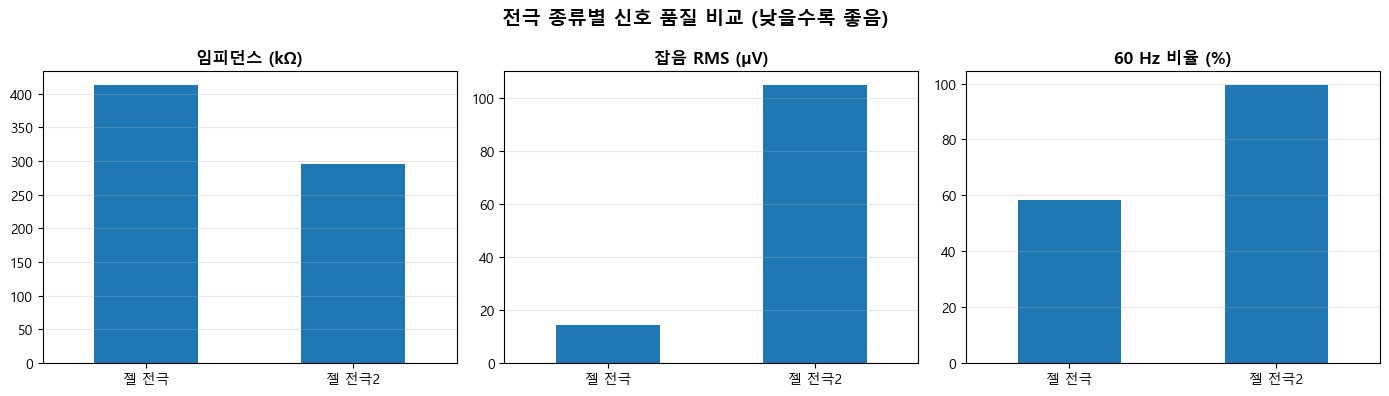

세 지표가 함께 움직이나요?
임피던스가 높은 전극일수록 잡음과 60 Hz 도 커지는 것이 일반적입니다.


In [11]:
# ===== 지금 쓰는 전극 이름을 적으세요 =====
ELECTRODE_NAME = '젤 전극2'      # 예: '건전극', '젤 전극', '스티커 전극'
# =========================================

NOISE_SEC = 8      # 잡음 측정 시간 (초)

if 'measure_impedance' not in dir():
    print('중단: 임피던스 점검 셀을 먼저 실행하세요.')
    print('      그 셀에서 measure_impedance() 함수를 정의합니다.')
    raise SystemExit

# 1-4(보드 사양) 셀을 건너뛰었을 때를 대비해 여기서 채운다.
# 아래 값들은 보드에 연결하지 않아도 조회할 수 있는 사양이다.
if 'EMG_CHANNELS' not in dir():
    FS           = BoardShim.get_sampling_rate(BOARD_ID)
    EMG_CHANNELS = BoardShim.get_emg_channels(BOARD_ID)
    N_CH         = len(EMG_CHANNELS)
    NYQUIST      = FS / 2
    print('참고: 1-4(보드 사양) 셀을 건너뛰어 여기서 자동으로 채웠습니다.')
    print(f'      FS={FS} Hz, 채널 {N_CH}개, 나이퀴스트 {NYQUIST:.0f} Hz')
    print()

# NumPy 2.0 에서 사다리꼴 적분 함수의 이름이 바뀌었다.
#   NumPy 1.x : np.trapz      (2.0 에서 제거됨)
#   NumPy 2.x : np.trapezoid  (1.x 에는 없음)
# 한쪽 이름만 쓰면 다른 버전에서 AttributeError 가 난다. 있는 쪽을 고른다.
_trapz = getattr(np, 'trapezoid', None) or getattr(np, 'trapz')

if not connected:
    print('보드가 연결되지 않았습니다. 5단계를 먼저 성공시키세요.')
else:
    print(f'[{ELECTRODE_NAME}] 측정을 시작합니다.')
    print()

    # --- 1) 임피던스 ---
    imp = measure_impedance(board, seconds=12)

    # --- 2) 잡음: 힘을 뺀 상태의 신호 ---
    print(f'잡음 측정 중... {NOISE_SEC}초 (힘을 빼고 가만히 계세요)')
    board.start_stream()
    time.sleep(1.0)
    board.get_board_data()
    time.sleep(NOISE_SEC)
    nd = board.get_board_data()
    board.stop_stream()

    sig = nd[EMG_CHANNELS, :]
    bb, aa = sp_signal.butter(4, [20 / NYQUIST, 95 / NYQUIST], btype='band')
    filt = np.array([sp_signal.filtfilt(bb, aa, sig[i]) for i in range(N_CH)])

    noise_rms = float(np.mean([np.sqrt(np.mean(filt[i] ** 2)) for i in range(N_CH)]))

    # 60 Hz 가 전체 파워에서 차지하는 비율
    ratios = []
    for i in range(N_CH):
        f, pxx = sp_signal.welch(sig[i], fs=FS, nperseg=min(256, sig.shape[1]))
        band = (f >= 20) & (f <= 95)
        near60 = (f >= 58) & (f <= 62)
        tot = _trapz(pxx[band], f[band])
        p60 = _trapz(pxx[near60], f[near60])
        ratios.append(100 * p60 / tot if tot > 0 else 0.0)
    hum_ratio = float(np.mean(ratios))

    imp_vals = [v for k, v in imp.items() if v is not None and k != 'REF']
    imp_mean = float(np.mean(imp_vals)) if imp_vals else float('nan')

    print()
    print('=' * 62)
    print(f'[{ELECTRODE_NAME}] 측정 결과')
    print('=' * 62)
    print(f'  임피던스 (채널 평균) : {imp_mean:8.1f} kΩ')
    print(f'  기준(REF) 임피던스   : {imp["REF"] if imp["REF"] is not None else float("nan"):8.1f} kΩ')
    print(f'  잡음 RMS             : {noise_rms:8.2f} µV')
    print(f'  60 Hz 비율           : {hum_ratio:8.1f} %')
    print('=' * 62)

    # --- 3) CSV 에 누적 ---
    out_dir = Path('..') / 'outputs'
    out_dir.mkdir(exist_ok=True)
    comp_path = out_dir / 'electrode_comparison.csv'

    row = {
        'time':        datetime.now().isoformat(timespec='seconds'),
        'electrode':   ELECTRODE_NAME,
        'imp_mean_kohm': round(imp_mean, 1),
        'imp_ref_kohm':  round(imp['REF'], 1) if imp['REF'] is not None else np.nan,
        'noise_rms_uv':  round(noise_rms, 2),
        'hum60_pct':     round(hum_ratio, 1),
        'board':       (globals().get('CONNECTED_BOARD') or {}).get('name', 'unknown'),
    }
    for k, v in imp.items():
        row[f'imp_{k}_kohm'] = round(v, 1) if v is not None else np.nan

    new_df = pd.DataFrame([row])
    if comp_path.exists():
        comp_df = pd.concat([pd.read_csv(comp_path), new_df], ignore_index=True)
    else:
        comp_df = new_df
    comp_df.to_csv(comp_path, index=False)

    print()
    print(f'기록 저장: {comp_path.resolve()}  (총 {len(comp_df)}건)')
    print()
    display(comp_df[['time', 'electrode', 'imp_mean_kohm', 'noise_rms_uv', 'hum60_pct']])

    # --- 4) 두 종류 이상 쌓이면 비교 그래프 ---
    summary = comp_df.groupby('electrode')[['imp_mean_kohm', 'noise_rms_uv', 'hum60_pct']].mean()
    if len(summary) >= 2:
        fig, axes = plt.subplots(1, 3, figsize=(14, 4))
        titles = [('imp_mean_kohm', '임피던스 (kΩ)'),
                  ('noise_rms_uv',  '잡음 RMS (µV)'),
                  ('hum60_pct',     '60 Hz 비율 (%)')]
        for ax, (col, title) in zip(axes, titles):
            summary[col].plot(kind='bar', ax=ax, color='#1f77b4')
            ax.set_title(title, fontweight='bold')
            ax.set_xlabel('')
            ax.tick_params(axis='x', rotation=0)
            ax.grid(alpha=0.3, axis='y')
        fig.suptitle('전극 종류별 신호 품질 비교 (낮을수록 좋음)',
                     fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

        print('세 지표가 함께 움직이나요?')
        print('임피던스가 높은 전극일수록 잡음과 60 Hz 도 커지는 것이 일반적입니다.')
    else:
        print('전극을 바꿔서 한 번 더 실행하면 비교 그래프가 나옵니다.')

---
# 2. 신호 수집

`start_stream()` 을 부르면 보드가 데이터를 보내기 시작하고,
BrainFlow가 내부 버퍼에 계속 쌓아 둡니다.

설정한 시간만큼 기다린 뒤 `get_board_data()` 로 한 번에 가져옵니다.

### 전극을 팔뚝에 붙이세요

- 4개 채널 전극을 **팔뚝의 서로 다른 근육 위**에 붙입니다
- 기준(레퍼런스) 전극은 **뼈 위**(손목 안쪽, 팔꿈치 돌출부 등 근육이 적은 곳)에
- 전극과 피부가 잘 밀착되어야 합니다

> 🧪 **해 볼 것**: 수집되는 동안 **주먹을 꽉 쥐었다 폈다** 반복하세요.
> 나중에 그래프에서 힘준 순간이 큰 파형으로 보입니다.

BrainFlow가 준 행렬에서 EMG 채널만 뽑아 표(DataFrame)로 바꿉니다. 이 형태가 되면 Excel처럼 다루기 쉽고, 나중에 CSV로 저장하기도 편합니다.

단위는 µV(마이크로볼트) 입니다.

In [7]:
if not connected:
    print('보드가 연결되지 않았습니다. 5단계를 먼저 성공시키세요.')
else:
    board.start_stream()
    print(f'{DURATION_SEC}초 동안 수집합니다.')
    print()

    for sec in range(DURATION_SEC):
        time.sleep(1)
        bar = '#' * (sec + 1) + '.' * (DURATION_SEC - sec - 1)
        print(f'  [{bar}] {sec + 1}/{DURATION_SEC} 초', end='\r')

    data = board.get_board_data()   # (행=채널, 열=시간)
    board.stop_stream()

    n_samples = data.shape[1]
    print()
    print()
    print('수집 완료')
    print(f'  데이터 형태 : {data.shape}  (행=채널, 열=시간)')
    print(f'  샘플 수     : {n_samples} 개')
    print(f'  실제 시간   : {n_samples / FS:.2f} 초')

    if n_samples == 0:
        print()
        print('샘플이 0개입니다. 전극이 연결되어 있는지, 보드가 켜져 있는지 확인하세요.')

emg = data[EMG_CHANNELS, :]                    # EMG 행만 추출 -> (4, N)
t   = np.arange(emg.shape[1]) / FS             # 시간축 (초)

df = pd.DataFrame(emg.T, columns=[f'Ch{i+1}' for i in range(N_CH)])
df.insert(0, 'time_sec', t)

print(f'표 크기: {df.shape[0]} 행 x {df.shape[1]} 열')
print()
print('처음 5개 샘플:')
display(df.head())

print()
print('채널별 기초 통계 (µV):')
display(df[[f'Ch{i+1}' for i in range(N_CH)]].describe().loc[['mean', 'std', 'min', 'max']].round(2))

10초 동안 수집합니다.

  [##########] 10/10 초

수집 완료
  데이터 형태 : (15, 2003)  (행=채널, 열=시간)
  샘플 수     : 2003 개
  실제 시간   : 10.02 초
표 크기: 2003 행 x 5 열

처음 5개 샘플:


,time_sec,Ch1,Ch2,Ch3,Ch4
0,0.000,-4.117630,-7.681755,-4.936668,2.101824
1,0.005,0.407649,3.556645,-1.540839,5.415375
2,0.010,-6.137176,-5.243340,-6.567264,-0.003740
3,0.015,-3.537945,-3.440708,-5.505133,-1.185548
4,0.020,0.781639,-3.549165,-1.230427,1.802632



채널별 기초 통계 (µV):


,Ch1,Ch2,Ch3,Ch4
mean,-1506.60,-704.54,-1264.59,-4569.76
std,5753.66,6900.90,8810.45,12214.05
min,-16313.58,-15686.28,-21719.30,-20403.77
max,13222.82,15686.28,15686.28,16681.74


In [14]:
# 섹션 2-1: 신호 저장 (선택)
out_dir = Path('..') / 'outputs'
out_dir.mkdir(exist_ok=True)

stamp = datetime.now().strftime('%Y%m%d_%H%M%S')
_board = globals().get('CONNECTED_BOARD', {})
_tag = (_board.get('name') or 'unknown').replace(' ', '')

save_df = df.copy()
save_df['board_name'] = _board.get('name', 'unknown')
save_df['board_mac']  = _board.get('mac', 'unknown')

csv_path = out_dir / f'ganglion_{_tag}_{stamp}.csv'
save_df.to_csv(csv_path, index=False)

print(f'저장: {csv_path}')

저장: ..\outputs\ganglion_Ganglion-c57c_20260725_203739.csv


In [8]:
# 섹션 2-2: 저장된 데이터 로드
import pandas as pd
import glob
from pathlib import Path

# 실제 저장된 파일 찾기
out_dir = Path('..') / 'outputs'
files = sorted(out_dir.glob('ganglion_*.csv'))

if not files:
    print('outputs/ 폴더에 파일이 없습니다.')
    print('먼저 섹션 2를 실행하고 저장해야 합니다.')
else:
    # 가장 최근 파일 로드
    csv_path = files[-1]
    print(f'로드: {csv_path.name}')
    
    df = pd.read_csv(csv_path)
    emg = df[[f'Ch{i+1}' for i in range(4)]].T.values
    t = df['time_sec'].values
    
    print(f'데이터 로드 완료: {emg.shape}')
    print()

    # ========== 섹션 1-4에서 정의해야 할 상수들 ==========
    FS           = 200                          # Ganglion 샘플 레이트 (Hz)
    BOARD_ID     = 1                            # Ganglion ID
    EMG_CHANNELS = [0, 1, 2, 3]                 # 4채널
    N_CH         = len(EMG_CHANNELS)
    NYQUIST      = FS / 2
    
    # ========== 섹션 4에서 필터 정의할 상수들 ==========
    LOW      = 20       # 저주파 컷오프 (Hz)
    HIGH     = 95       # 고주파 컷오프 (Hz)
    NOTCH    = 60       # 노치 필터 중심 (Hz)
    Q        = 30       # 노치 필터 Q값
    ORDER    = 4        # 필터 차수
    
    print(f'상수 설정 완료:')
    print(f'  FS={FS} Hz, N_CH={N_CH}, Nyquist={NYQUIST} Hz')
    print(f'  필터: {LOW}-{HIGH} Hz bandpass, {NOTCH} Hz notch')

로드: ganglion_Ganglion-c57c_20260725_203739.csv
데이터 로드 완료: (4, 2003)

상수 설정 완료:
  FS=200 Hz, N_CH=4, Nyquist=100.0 Hz
  필터: 20-95 Hz bandpass, 60 Hz notch


---
# 3· Data plot

수집한 EMG 를 **두 가지 방식으로** 봅니다. 같은 신호지만 보이는 것이 다릅니다.

| 그림 | 가로축 | 세로축 | 알 수 있는 것 |
| --- | --- | --- | --- |
| **① 원본 파형** | 시간(초) | 전압(µV) | **언제** 힘을 줬는가 |
| **② 단측 진폭 스펙트럼** | 주파수(Hz) | 진폭(µV) | **어떤 주파수**가 얼마나 들어있는가 |

---

## ① 원본 파형 — 아무 처리도 하지 않은 날것의 EMG

대개 이렇게 보입니다.

- 신호 전체가 0 에서 멀리 떨어져 위아래로 떠 있음 → **DC 오프셋**
- 천천히 흐르는 큰 물결 → **움직임 잡음** (전극이 흔들리거나 케이블이 움직일 때)
- 촘촘한 잔물결 → **60 Hz 전원 잡음**

힘을 준 구간에서 파형이 두꺼워지는 것이 보이면 전극이 잘 붙은 것입니다.

하지만 파형만 봐서는 **잡음이 몇 Hz 짜리인지** 알 수 없습니다.
DC 오프셋도, 움직임 잡음도, 60 Hz 도 전부 뒤엉켜 하나의 선으로 보이기 때문입니다.

---

## ② 단측 진폭 스펙트럼 (Single-Sided Amplitude Spectrum)

그래서 같은 신호를 **주파수로 분해**해서 봅니다. 도구는 **FFT(고속 푸리에 변환)** 입니다.

> 뒤섞인 파형을 **"몇 Hz 짜리 파동이 얼마나 섞여 있는가"** 로 분해한다.

전체 수집 구간을 **하나로 뭉쳐서** 계산합니다. 시간 정보는 버리는 대신,
주파수 성분을 아주 정밀하게 볼 수 있습니다.

### 왜 "단측(single-sided)" 인가

실수 신호의 FFT 결과는 **0 Hz 를 기준으로 좌우 대칭**입니다. 절반은 중복입니다.
그래서 양의 주파수(0 ~ fs/2)만 남기고, **버린 절반의 몫을 살린 쪽에 더해 2배**를 곱합니다.
(0 Hz 와 나이퀴스트는 짝이 없으므로 2배에서 제외)

계산 순서는 MATLAB 의 `fft` 예제와 같습니다.

```
Y  = fft(x)              전체 FFT (양·음 주파수)
P2 = |Y| / L             길이로 나눠 진폭으로 환산   (L = 샘플 수)
P1 = P2[0 : L/2+1]       절반만 취함 = 단측
P1[1:-1] *= 2            버린 절반의 몫을 되살림
f  = fs * (0:L/2) / L    주파수 축
```

파이썬에서는 `np.fft.rfft` 가 "실수 신호의 양의 주파수만" 을 바로 돌려주므로
절반 잘라내는 과정이 생략됩니다.

### 무엇을 봐야 하는가

| 주파수 | 무엇 | 어떻게 보이나 |
| --- | --- | --- |
| **0 ~ 20 Hz** | DC 오프셋, 움직임 잡음 | 왼쪽 끝이 크게 솟음 |
| **20 ~ 95 Hz** | **진짜 EMG 신호** | 넓게 퍼진 언덕 |
| **60 Hz** | **전원 잡음** | 뾰족한 막대 하나 ⚡ |

EMG 처럼 불규칙한 신호는 넓은 대역에 **퍼진 언덕**으로 나타나고,
콘센트에서 들어온 60 Hz 처럼 규칙적인 잡음은 **한 점에 뾰족한 막대**로 나타납니다.
이 모양 차이로 신호와 잡음을 구분합니다.

> ⚡ **60 Hz 에 뾰족한 봉우리가 보인다면** 그것이 전원 잡음입니다.
> **이것이 바로 다음 단계에서 노치 필터가 필요한 이유입니다.**

### 이 보드의 가로축 한계

첨부 예제 그림은 500 Hz 까지 있지만, 그것은 1000 Hz 로 측정한 경우입니다.
이 보드는 **200 Hz** 로 측정하므로 **100 Hz 까지만** 볼 수 있습니다 (나이퀴스트 = 200÷2).

### 창(window) 함수 — 선택 사항

FFT 는 신호가 **무한히 반복된다고 가정**합니다.
잘린 양 끝이 서로 안 맞으면 없던 주파수가 번지는데(누설, leakage),
양 끝을 부드럽게 0 으로 낮추는 **해닝 창**을 곱하면 줄어듭니다.

`USE_WINDOW = False` 가 기본값이고, MATLAB 예제와 동일한 계산입니다.

> 🧪 **해 볼 것**: `USE_WINDOW` 를 `True` 로 바꿔 60 Hz 봉우리가
> 얼마나 더 날카로워지는지 비교해 보세요.

C:\Users\Owner\AppData\Local\Temp\ipykernel_18744\1306603881.py:13: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from current font.
  plt.tight_layout()
C:\Users\Owner\AppData\Local\Temp\ipykernel_18744\1306603881.py:13: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from current font.
  plt.tight_layout()
C:\Users\Owner\AppData\Local\Temp\ipykernel_18744\1306603881.py:13: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from current font.
  plt.tight_layout()
C:\Users\Owner\AppData\Local\Temp\ipykernel_18744\1306603881.py:13: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from current font.
  plt.tight_layout()
C:\Users\Owner\AppData\Local\Temp\ipykernel_18744\1306603881.py:13: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from current font.
  plt.tight_layout()
C:\Users\Owner\AppData\Local\Temp\ipykernel_18744\1306603881.py:13: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from current font.
  plt.tight_layout()

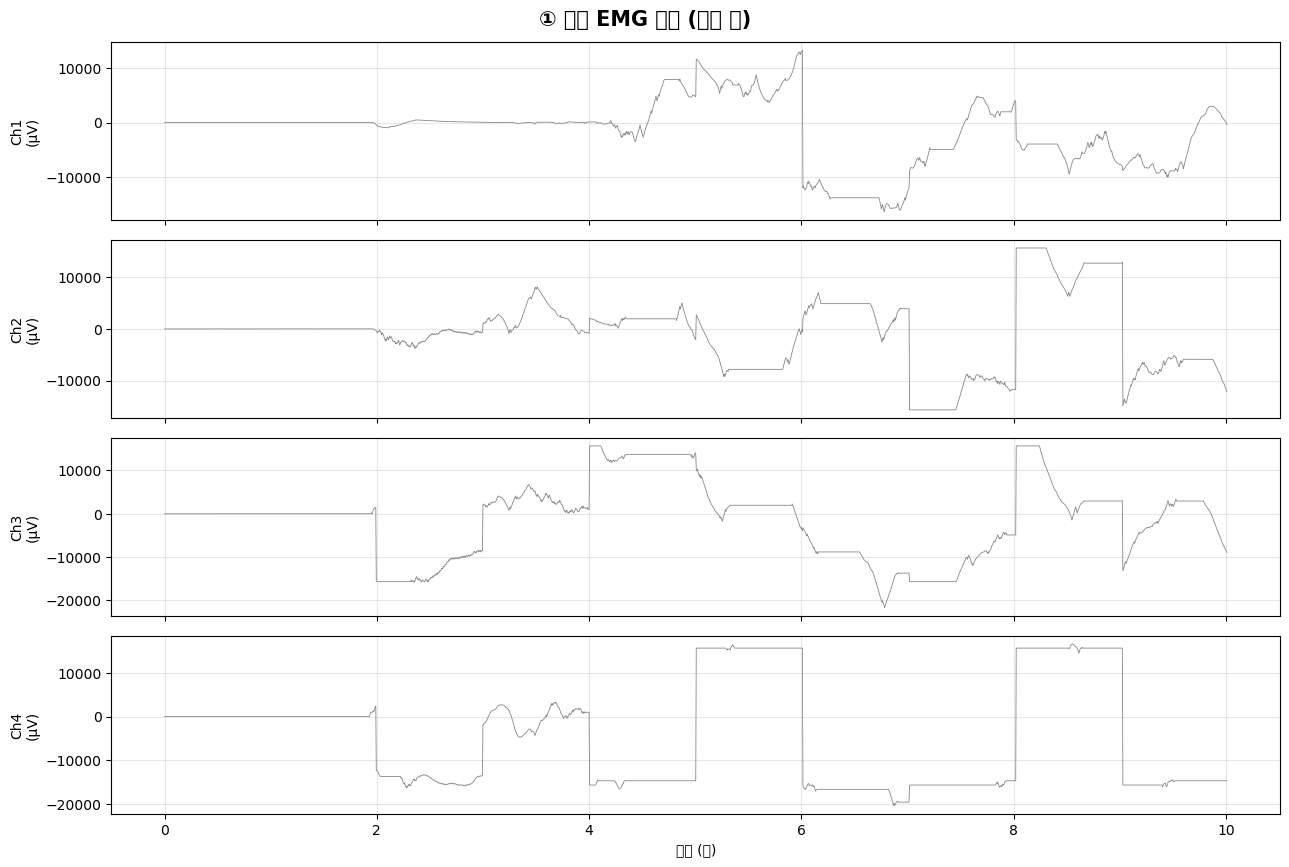

C:\Users\Owner\AppData\Local\Temp\ipykernel_18744\1306603881.py:99: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from current font.
  plt.tight_layout()
C:\Users\Owner\AppData\Local\Temp\ipykernel_18744\1306603881.py:99: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from current font.
  plt.tight_layout()
C:\Users\Owner\AppData\Local\Temp\ipykernel_18744\1306603881.py:99: UserWarning: Glyph 51105 (\N{HANGUL SYLLABLE JAB}) missing from current font.
  plt.tight_layout()
C:\Users\Owner\AppData\Local\Temp\ipykernel_18744\1306603881.py:99: UserWarning: Glyph 51020 (\N{HANGUL SYLLABLE EUM}) missing from current font.
  plt.tight_layout()
C:\Users\Owner\AppData\Local\Temp\ipykernel_18744\1306603881.py:99: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from current font.
  plt.tight_layout()
C:\Users\Owner\AppData\Local\Temp\ipykernel_18744\1306603881.py:99: UserWarning: Glyph 50669 (\N{HANGUL SYLLABLE YEOG}) missing from current font.
  plt.tight_layo

채널별 DC 오프셋(평균) 과 진폭(표준편차)
--------------------------------------------------
채널                 평균 (µV)           표준편차 (µV)
--------------------------------------------------
Ch1                 -1506.6              5752.2
Ch2                  -704.5              6899.2
Ch3                 -1264.6              8808.2
Ch4                 -4569.8             12211.0
--------------------------------------------------
평균이 0 에서 크게 벗어나 있으면 DC 오프셋이 있다는 뜻입니다.

FFT 설정
  샘플 수      : 2003 개  (10.02 초)
  주파수 분해능: 0.100 Hz
  가로축 상한  : 100 Hz (나이퀴스트 = 200/2)
  창 함수      : 없음 (MATLAB 예제와 동일)


C:\Users\Owner\AppData\Local\Temp\ipykernel_18744\1306603881.py:99: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from current font.
  plt.tight_layout()
C:\Users\Owner\AppData\Local\Temp\ipykernel_18744\1306603881.py:99: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from current font.
  plt.tight_layout()
C:\Users\Owner\AppData\Local\Temp\ipykernel_18744\1306603881.py:99: UserWarning: Glyph 51652 (\N{HANGUL SYLLABLE JIN}) missing from current font.
  plt.tight_layout()
C:\Users\Owner\AppData\Local\Temp\ipykernel_18744\1306603881.py:99: UserWarning: Glyph 54253 (\N{HANGUL SYLLABLE POG}) missing from current font.
  plt.tight_layout()
C:\Users\Owner\AppData\Local\Temp\ipykernel_18744\1306603881.py:99: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from current font.
  plt.tight_layout()
C:\Users\Owner\AppData\Local\Temp\ipykernel_18744\1306603881.py:99: UserWarning: Glyph 54169 (\N{HANGUL SYLLABLE PEG}) missing from current font.
  plt.tight_layout

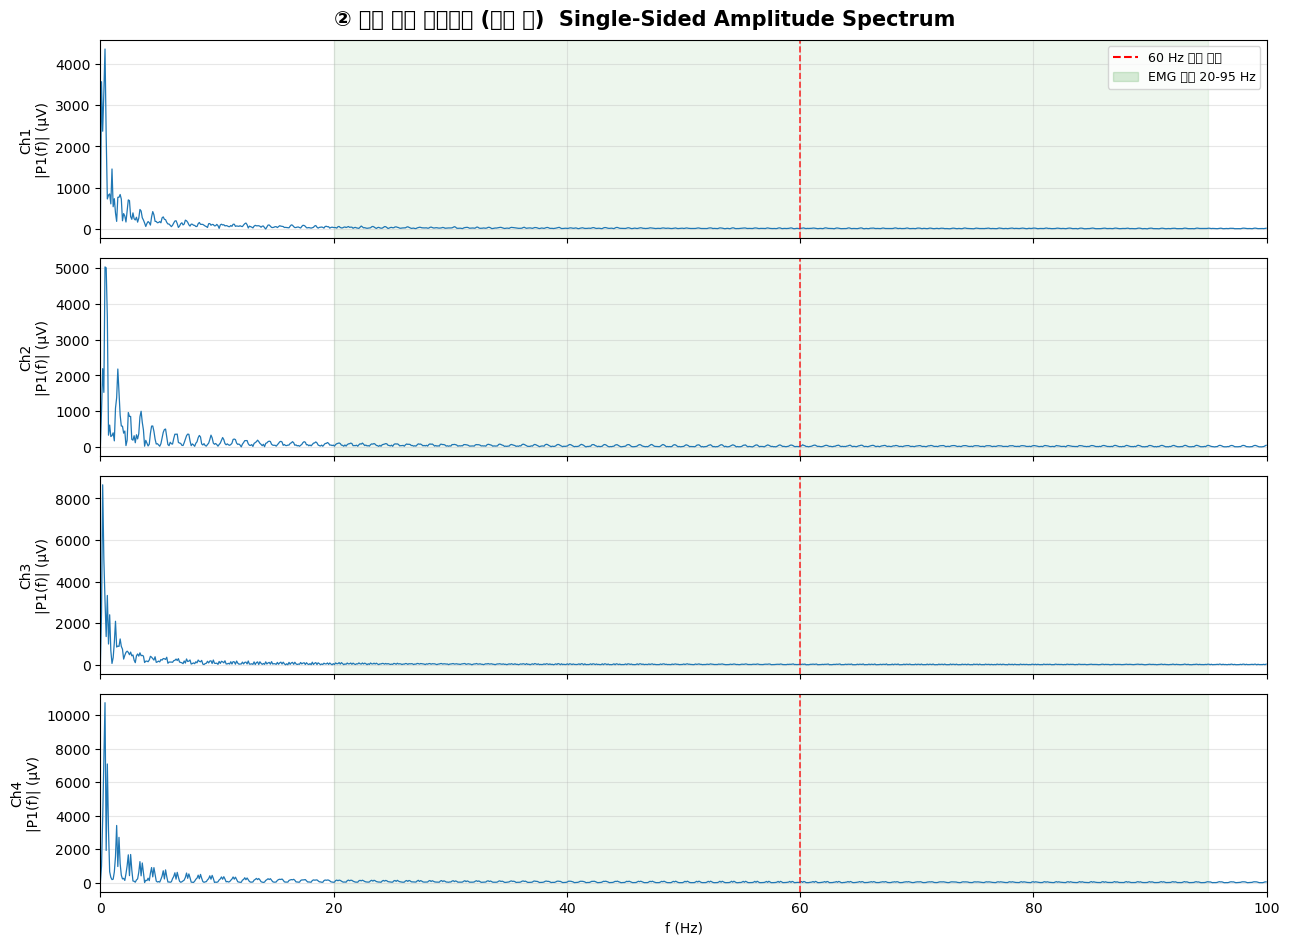

채널별 60 Hz 전원 잡음
--------------------------------------------------------------
채널               60Hz 진폭          EMG대역 평균          배율
--------------------------------------------------------------
Ch1               27.81µV           19.75µV        1.4배
Ch2               60.20µV           30.48µV        2.0배
Ch3               43.22µV           25.75µV        1.7배
Ch4               82.41µV           44.12µV        1.9배
--------------------------------------------------------------

60 Hz 봉우리가 주변 EMG 보다 몇 배나 큰지 보세요.
배율이 클수록 전원 잡음을 많이 주워 온 것이고,
보통 전극 접촉이 나쁠수록(임피던스가 높을수록) 이 값이 커집니다.


In [9]:
# ============================================================
# 3-1. 원본 파형 (시간 영역)
# ============================================================
fig, axes = plt.subplots(N_CH, 1, figsize=(13, 2.2 * N_CH), sharex=True)
fig.suptitle('① 원본 EMG 신호 (필터 전)', fontsize=15, fontweight='bold')

for i in range(N_CH):
    axes[i].plot(t, emg[i], linewidth=0.6, color='#888888')
    axes[i].set_ylabel(f'Ch{i+1}\n(µV)')
    axes[i].grid(alpha=0.3)

axes[-1].set_xlabel('시간 (초)')
plt.tight_layout()
plt.show()

print('채널별 DC 오프셋(평균) 과 진폭(표준편차)')
print('-' * 50)
print(f'{"채널":<8}{"평균 (µV)":>18}{"표준편차 (µV)":>20}')
print('-' * 50)
for i in range(N_CH):
    print(f'Ch{i+1:<7}{emg[i].mean():>18.1f}{emg[i].std():>20.1f}')
print('-' * 50)
print('평균이 0 에서 크게 벗어나 있으면 DC 오프셋이 있다는 뜻입니다.')


# ============================================================
# 3-2. 단측 진폭 스펙트럼 (Single-Sided Amplitude Spectrum)
#      전체 시간 구간을 하나로 뭉쳐서 주파수 성분을 본다
# ============================================================
# ---- 설정 ----
USE_WINDOW = False    # True 로 바꾸면 해닝 창 적용 (누설 감소)
# --------------

def single_sided_spectrum(x, fs, use_window=False):
    '''단측 진폭 스펙트럼을 구한다. (MATLAB fft 예제와 같은 계산)

        Y  = fft(x)            전체 FFT
        P2 = |Y| / L           길이로 나눠 진폭 환산
        P1 = P2[:L//2+1]       절반만 = 단측
        P1[1:-1] *= 2          버린 절반의 몫을 되살림

    np.fft.rfft 는 양의 주파수만 바로 돌려주므로 절반 자르는 과정이 없다.

    반환: (주파수 배열 Hz, 진폭 배열 - 입력과 같은 단위)
    '''
    L  = len(x)
    xc = x - x.mean()                      # DC 오프셋 제거 (0 Hz 가 화면을 지배하지 않도록)

    if use_window:
        w    = np.hanning(L)
        Y    = np.fft.rfft(xc * w)
        norm = np.sum(w) / 2.0             # 창이 진폭을 깎은 만큼 되돌린다
    else:
        Y    = np.fft.rfft(xc)
        norm = L / 2.0                     # 창 없음 = MATLAB 예제와 동일

    P1 = np.abs(Y) / norm                  # 이미 2배가 반영된 형태
    P1[0] /= 2                             # 0 Hz 는 짝이 없으므로 2배 제외
    if L % 2 == 0:
        P1[-1] /= 2                        # 나이퀴스트도 짝이 없음

    f = np.fft.rfftfreq(L, d=1.0 / fs)
    return f, P1


print()
print('=' * 56)
print('FFT 설정')
print('=' * 56)
print(f'  샘플 수      : {emg.shape[1]} 개  ({emg.shape[1] / FS:.2f} 초)')
print(f'  주파수 분해능: {FS / emg.shape[1]:.3f} Hz')
print(f'  가로축 상한  : {NYQUIST:.0f} Hz (나이퀴스트 = {FS}/2)')
print(f'  창 함수      : {"해닝" if USE_WINDOW else "없음 (MATLAB 예제와 동일)"}')
print('=' * 56)

fig, axes = plt.subplots(N_CH, 1, figsize=(13, 2.4 * N_CH), sharex=True)
fig.suptitle('② 단측 진폭 스펙트럼 (필터 전)  Single-Sided Amplitude Spectrum',
             fontsize=15, fontweight='bold')

for i in range(N_CH):
    f, P1 = single_sided_spectrum(emg[i], FS, USE_WINDOW)

    axes[i].plot(f, P1, linewidth=0.9, color='#1f77b4')

    # 60 Hz 전원 잡음 위치
    axes[i].axvline(60, color='red', linestyle='--', linewidth=1.2, alpha=0.8)
    # EMG 로 쓸 대역
    axes[i].axvspan(20, 95, color='green', alpha=0.07)

    axes[i].set_ylabel(f'Ch{i+1}\n|P1(f)| (µV)')
    axes[i].set_xlim(0, NYQUIST)
    axes[i].grid(alpha=0.3)
    if i == 0:
        axes[i].plot([], [], color='red', linestyle='--', label='60 Hz 전원 잡음')
        axes[i].fill_between([], [], color='green', alpha=0.15, label='EMG 대역 20-95 Hz')
        axes[i].legend(loc='upper right', fontsize=9)

axes[-1].set_xlabel('f (Hz)')
plt.tight_layout()
plt.show()

# 60 Hz 가 얼마나 큰지 숫자로도 확인
print('채널별 60 Hz 전원 잡음')
print('-' * 62)
print(f'{"채널":<8}{"60Hz 진폭":>16}{"EMG대역 평균":>18}{"배율":>12}')
print('-' * 62)
for i in range(N_CH):
    f, P1 = single_sided_spectrum(emg[i], FS, USE_WINDOW)
    near60 = (f >= 58) & (f <= 62)
    band   = (f >= 20) & (f <= 95) & ~near60
    a60    = P1[near60].max()
    abase  = P1[band].mean() if band.any() else 0.0
    ratio  = a60 / abase if abase > 0 else 0.0
    print(f'Ch{i+1:<7}{a60:>14.2f}µV{abase:>16.2f}µV{ratio:>11.1f}배')
print('-' * 62)
print()
print('60 Hz 봉우리가 주변 EMG 보다 몇 배나 큰지 보세요.')
print('배율이 클수록 전원 잡음을 많이 주워 온 것이고,')
print('보통 전극 접촉이 나쁠수록(임피던스가 높을수록) 이 값이 커집니다.')

---
# 4. 데이터 필터링

EMG 에서 쓸모 있는 성분만 남기고 나머지를 걷어냅니다.

### ① 대역통과 필터 (Bandpass) — 20~95 Hz

| 차단 | 이유 |
| --- | --- |
| **20 Hz 아래** 제거 | DC 오프셋, 전극 움직임 잡음(motion artifact) |
| **95 Hz 위** 제거 | 고주파 잡음 |

20 Hz 는 근전도 분야의 표준 저역 차단 주파수입니다.
움직임 잡음은 대부분 20 Hz 아래에 몰려 있습니다.

### ② 노치 필터 (Notch) — 60 Hz

한국 전원 주파수인 **60 Hz** 만 콕 집어 제거합니다.
(유럽·일본 동부는 50 Hz)

### ⚠️ 왜 95 Hz 인가 — 나이퀴스트 한계

EMG 는 원래 **450 Hz** 까지 성분이 있고, 에너지는 50~150 Hz 부근에 가장 많습니다.
그런데 200 Hz 로 측정하면 **100 Hz 까지만** 표현할 수 있습니다 (나이퀴스트 = 200÷2).

경계값인 100 Hz 는 필터가 불안정해지므로 **95 Hz** 로 둡니다.
EMG 의 위쪽 절반은 못 보지만, **신호의 세기**를 쓰는 용도에는 충분합니다.

> 🧪 **해 볼 것**: `LOW` 값을 5, 20, 40 으로 바꿔가며 재실행해 보세요.
> 낮게 두면 움직임 잡음이 남고, 너무 높이면 신호까지 깎입니다.

In [10]:
# ---- 필터 설정 (바꿔가며 실험해 보세요) ----
LOW   = 20.0    # Hz, 이보다 낮은 성분 제거 (움직임 잡음)
HIGH  = 95.0    # Hz, 이보다 높은 성분 제거 (나이퀴스트 100Hz 회피)
NOTCH = 60.0    # Hz, 전원 잡음 (한국 60Hz / 유럽 50Hz)
ORDER = 4
# -------------------------------------------

b_bp, a_bp = sp_signal.butter(ORDER, [LOW / NYQUIST, HIGH / NYQUIST], btype='band')
b_no, a_no = sp_signal.iirnotch(NOTCH / NYQUIST, Q=30)

filtered = np.zeros_like(emg)
for i in range(N_CH):
    x = sp_signal.filtfilt(b_bp, a_bp, emg[i])   # 대역통과
    x = sp_signal.filtfilt(b_no, a_no, x)        # 노치
    filtered[i] = x

print(f'필터 적용 완료 : {LOW}-{HIGH} Hz 대역통과 + {NOTCH} Hz 노치')
print(f'나이퀴스트 주파수 : {NYQUIST} Hz  (이보다 높은 주파수는 볼 수 없음)')
print()
print('채널별 변화 (표준편차, µV)')
print('-' * 46)
print(f'{"채널":<8}{"필터 전":>14}{"필터 후":>14}')
print('-' * 46)
for i in range(N_CH):
    print(f'Ch{i+1:<7}{emg[i].std():>14.2f}{filtered[i].std():>14.2f}')
print('-' * 46)
print()
print('필터 후 표준편차가 크게 줄었다면, 그만큼 잡음이 많았다는 뜻입니다.')

필터 적용 완료 : 20.0-95.0 Hz 대역통과 + 60.0 Hz 노치
나이퀴스트 주파수 : 100.0 Hz  (이보다 높은 주파수는 볼 수 없음)

채널별 변화 (표준편차, µV)
----------------------------------------------
채널                필터 전          필터 후
----------------------------------------------
Ch1             5752.22        395.75
Ch2             6899.17        640.14
Ch3             8808.25        532.08
Ch4            12211.00        958.71
----------------------------------------------

필터 후 표준편차가 크게 줄었다면, 그만큼 잡음이 많았다는 뜻입니다.


---
# 4-1. 필터 전후 비교

같은 신호를 겹쳐 그려 필터가 무엇을 걷어냈는지 눈으로 확인합니다.

회색이 원본, 파란색이 필터 후입니다.
필터 후 신호가 0을 중심으로 정렬되고, 힘준 구간만 두꺼워지는 것이 보여야 합니다.

C:\Users\Owner\AppData\Local\Temp\ipykernel_18744\1894610185.py:15: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from current font.
  plt.tight_layout()
C:\Users\Owner\AppData\Local\Temp\ipykernel_18744\1894610185.py:15: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from current font.
  plt.tight_layout()
C:\Users\Owner\AppData\Local\Temp\ipykernel_18744\1894610185.py:15: UserWarning: Glyph 54596 (\N{HANGUL SYLLABLE PIL}) missing from current font.
  plt.tight_layout()
C:\Users\Owner\AppData\Local\Temp\ipykernel_18744\1894610185.py:15: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from current font.
  plt.tight_layout()
C:\Users\Owner\AppData\Local\Temp\ipykernel_18744\1894610185.py:15: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from current font.
  plt.tight_layout()
C:\Users\Owner\AppData\Local\Temp\ipykernel_18744\1894610185.py:15: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from current font.
  plt.tight_layout()

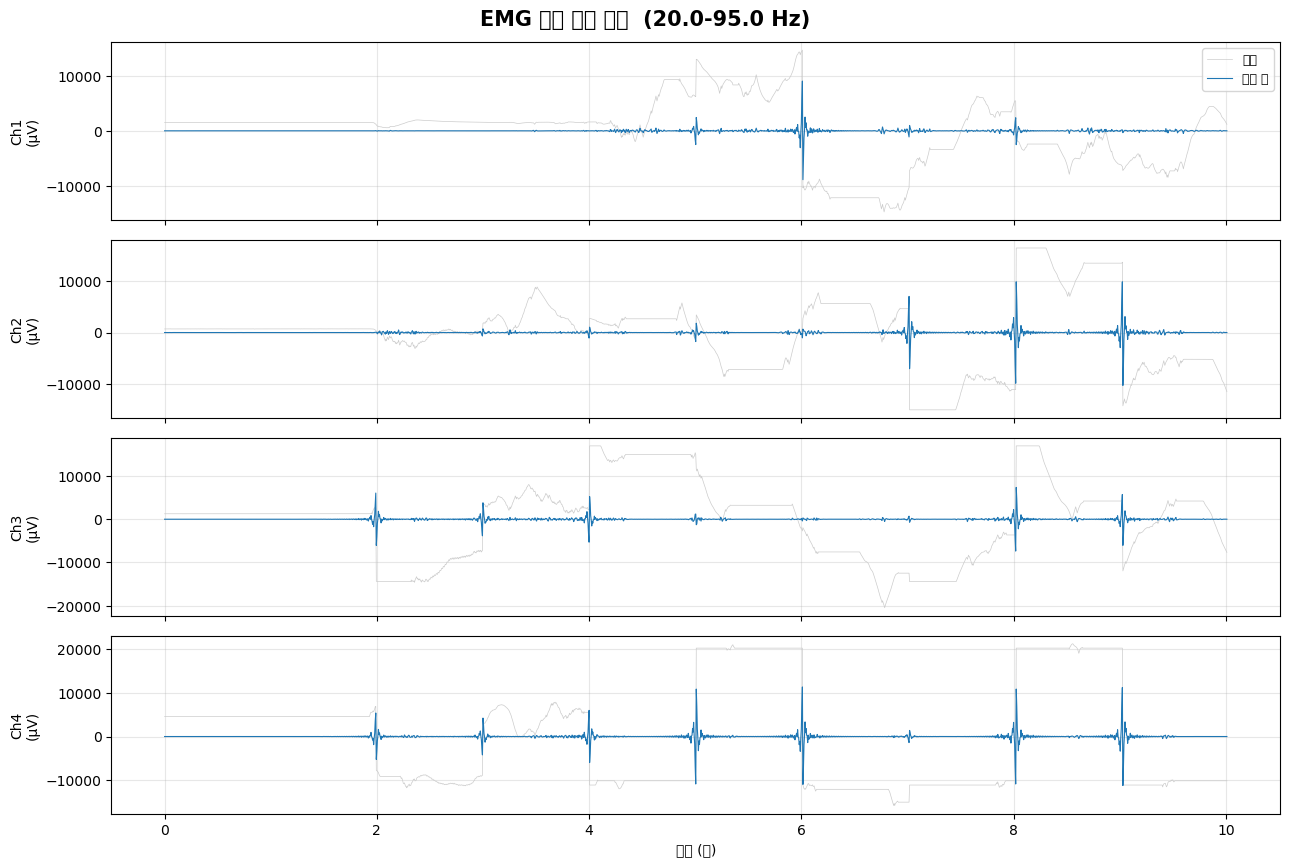

In [11]:
fig, axes = plt.subplots(N_CH, 1, figsize=(13, 2.2 * N_CH), sharex=True)
fig.suptitle(f'EMG 필터 전후 비교  ({LOW}-{HIGH} Hz)', fontsize=15, fontweight='bold')

for i in range(N_CH):
    axes[i].plot(t, emg[i] - emg[i].mean(), linewidth=0.5,
                 color='#cccccc', label='원본')
    axes[i].plot(t, filtered[i], linewidth=0.8,
                 color='#1f77b4', label='필터 후')
    axes[i].set_ylabel(f'Ch{i+1}\n(µV)')
    axes[i].grid(alpha=0.3)
    if i == 0:
        axes[i].legend(loc='upper right', fontsize=9)

axes[-1].set_xlabel('시간 (초)')
plt.tight_layout()
plt.show()

---
## 4-2 · 필터 전후 비교 (주파수 영역)

같은 신호를 주파수에서도 봅니다.
**빨간 점선(60 Hz)의 뾰족한 봉우리가 사라졌는지** 확인하세요.

이것이 필터가 실제로 일을 했다는 가장 확실한 증거입니다.

C:\Users\Owner\AppData\Local\Temp\ipykernel_18744\836861646.py:40: UserWarning: Glyph 54596 (\N{HANGUL SYLLABLE PIL}) missing from current font.
  plt.tight_layout()
C:\Users\Owner\AppData\Local\Temp\ipykernel_18744\836861646.py:40: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from current font.
  plt.tight_layout()
C:\Users\Owner\AppData\Local\Temp\ipykernel_18744\836861646.py:40: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from current font.
  plt.tight_layout()
C:\Users\Owner\AppData\Local\Temp\ipykernel_18744\836861646.py:40: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from current font.
  plt.tight_layout()
C:\Users\Owner\AppData\Local\Temp\ipykernel_18744\836861646.py:40: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from current font.
  plt.tight_layout()
C:\Users\Owner\AppData\Local\Temp\ipykernel_18744\836861646.py:40: UserWarning: Glyph 54028 (\N{HANGUL SYLLABLE PA}) missing from current font.
  plt.tight_layout()
C:\Use

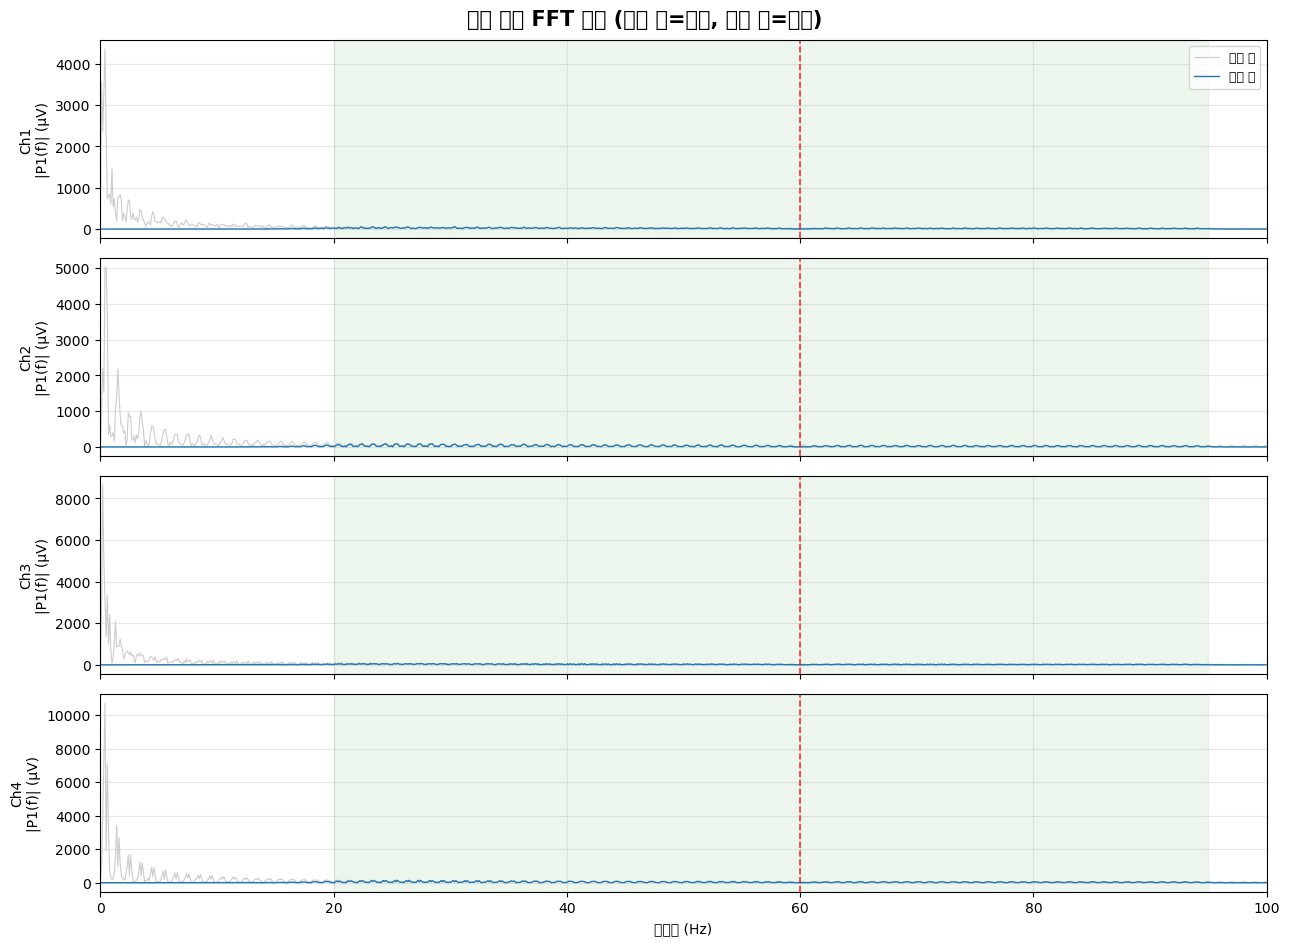

60 Hz 진폭 변화
--------------------------------------------------------------
채널                필터 전          필터 후             감소율
--------------------------------------------------------------
Ch1              27.81µV         21.22µV           23.7%
Ch2              60.20µV         37.90µV           37.0%
Ch3              43.22µV         24.79µV           42.7%
Ch4              82.41µV         59.01µV           28.4%
--------------------------------------------------------------
70% 이상 감소하면 60 Hz 제거 완료.


In [12]:
fig, axes = plt.subplots(N_CH, 1, figsize=(13, 2.4 * N_CH), sharex=True)
fig.suptitle('필터 전후 FFT 비교 (필터 전=회색, 필터 후=파랑)',
             fontsize=15, fontweight='bold')

_trapz = getattr(np, 'trapezoid', None) or getattr(np, 'trapz')

def single_sided_spectrum(x, fs, use_window=False):
    L = len(x)
    xc = x - x.mean()
    if use_window:
        w = np.hanning(L)
        Y = np.fft.rfft(xc * w)
        norm = np.sum(w) / 2.0
    else:
        Y = np.fft.rfft(xc)
        norm = L / 2.0
    P1 = np.abs(Y) / norm
    P1[0] /= 2
    if L % 2 == 0:
        P1[-1] /= 2
    f = np.fft.rfftfreq(L, d=1.0 / FS)
    return f, P1

for i in range(N_CH):
    f0, P0 = single_sided_spectrum(emg[i], FS, False)
    f1, P1 = single_sided_spectrum(filtered[i], FS, False)

    axes[i].plot(f0, P0, linewidth=0.8, color='#cccccc', label='필터 전')
    axes[i].plot(f1, P1, linewidth=1.0, color='#1f77b4', label='필터 후')
    axes[i].axvline(NOTCH, color='red', linestyle='--', linewidth=1.2, alpha=0.8)
    axes[i].axvspan(LOW, HIGH, color='green', alpha=0.07)

    axes[i].set_ylabel(f'Ch{i+1}\n|P1(f)| (µV)')
    axes[i].set_xlim(0, NYQUIST)
    axes[i].grid(alpha=0.3)
    if i == 0:
        axes[i].legend(loc='upper right', fontsize=9)

axes[-1].set_xlabel('주파수 (Hz)')
plt.tight_layout()
plt.show()

# 60 Hz 감소율
print('60 Hz 진폭 변화')
print('-' * 62)
print(f'{"채널":<8}{"필터 전":>14}{"필터 후":>14}{"감소율":>16}')
print('-' * 62)
for i in range(N_CH):
    f0, P0 = single_sided_spectrum(emg[i], FS, False)
    f1, P1 = single_sided_spectrum(filtered[i], FS, False)
    near60_0 = (f0 >= 58) & (f0 <= 62)
    near60_1 = (f1 >= 58) & (f1 <= 62)
    a0 = P0[near60_0].max() if near60_0.any() else 0.0
    a1 = P1[near60_1].max() if near60_1.any() else 0.0
    drop = 100 * (1 - a1 / a0) if a0 > 0 else 0.0
    print(f'Ch{i+1:<7}{a0:>13.2f}µV{a1:>14.2f}µV{drop:>15.1f}%')
print('-' * 62)
print('70% 이상 감소하면 60 Hz 제거 완료.')

---
## 4-2. RMS — 근육이 얼마나 힘을 쓰는가

**RMS(제곱평균제곱근)** 는 신호가 얼마나 강한지를 하나의 숫자로 나타냅니다.

$$\text{RMS} = \sqrt{\frac{1}{N}\sum_{i=1}^{N} x_i^2}$$

EMG 는 0을 중심으로 위아래로 진동하므로 그냥 평균을 내면 0에 가깝습니다.
제곱해서 부호를 없앤 뒤 평균을 내야 **실제 활동량**이 나옵니다.

**왜 중요한가**: 근육에 힘을 줄수록 RMS 가 뚜렷하게 올라갑니다.
그래서 *RMS 가 기준값을 넘으면 모터를 움직인다* 같은 제어가 가능합니다.
2차시에서 이 값을 그대로 머신러닝 입력으로 씁니다.

아래는 **짧은 구간마다 RMS를 계산**해서 시간에 따라 힘이 어떻게 변하는지 봅니다.

> 🧪 **해 볼 것**: 수집할 때 약하게 → 중간 → 세게 순서로 힘을 줬다면,
> RMS 가 계단처럼 올라가는 것이 보일 것입니다.

슬라이딩 윈도우 RMS: 0.25초 윈도우, 2003개 점



C:\Users\Owner\AppData\Local\Temp\ipykernel_18744\3263609831.py:35: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from current font.
  plt.tight_layout()
C:\Users\Owner\AppData\Local\Temp\ipykernel_18744\3263609831.py:35: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from current font.
  plt.tight_layout()
C:\Users\Owner\AppData\Local\Temp\ipykernel_18744\3263609831.py:35: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from current font.
  plt.tight_layout()
C:\Users\Owner\AppData\Local\Temp\ipykernel_18744\3263609831.py:35: UserWarning: Glyph 44540 (\N{HANGUL SYLLABLE GEUN}) missing from current font.
  plt.tight_layout()
C:\Users\Owner\AppData\Local\Temp\ipykernel_18744\3263609831.py:35: UserWarning: Glyph 50977 (\N{HANGUL SYLLABLE YUG}) missing from current font.
  plt.tight_layout()
C:\Users\Owner\AppData\Local\Temp\ipykernel_18744\3263609831.py:35: UserWarning: Glyph 54876 (\N{HANGUL SYLLABLE HWAL}) missing from current font.
  plt.tight_layout(

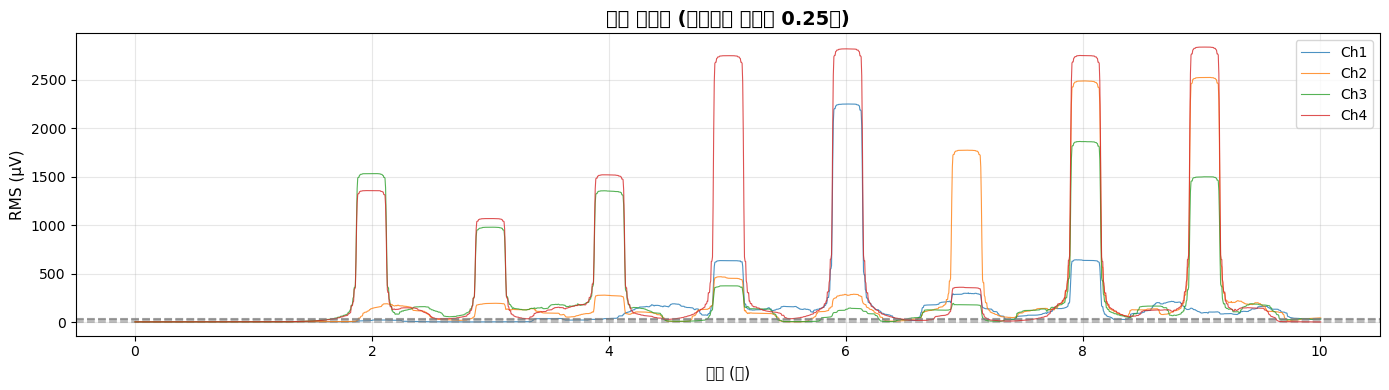

채널별 평균 RMS
--------------------------------------------------
채널             평균 RMS (µV)       최대 RMS (µV)
--------------------------------------------------
Ch1                   158.5            2251.9
Ch2                   268.8            2525.4
Ch3                   265.3            1864.7
Ch4                   460.5            2838.8
--------------------------------------------------
힘을 준 채널의 RMS 가 확실히 높다면 전극이 잘 붙은 것입니다.


In [13]:
# 섹션 4-2: 슬라이딩 윈도우 RMS
WINDOW_SEC = 0.25                      # RMS 계산 구간 길이 (초)
win        = int(FS * WINDOW_SEC)

# 슬라이딩 윈도우 - 각 샘플마다 윈도우 이동하며 RMS 계산
rms_time = t
rms = np.zeros((N_CH, len(t)))

for i in range(N_CH):
    for j in range(len(t)):
        # 현재 샘플 중심으로 윈도우
        start = max(0, j - win // 2)
        end = min(len(t), j + win // 2)
        rms[i, j] = np.sqrt(np.mean(filtered[i, start:end]**2))

print(f'슬라이딩 윈도우 RMS: {WINDOW_SEC}초 윈도우, {len(t)}개 점')
print()

# 활성 판정 기준 - 쉬고 있을 때 RMS 보다 조금 높게 잡는다
threshold = {}
for i in range(N_CH):
    noise_rms = np.percentile(rms[i], 25)  # 아래쪽 25% = 쉬는 시간
    threshold[i] = noise_rms * 1.5

fig, ax = plt.subplots(figsize=(14, 4))
for i in range(N_CH):
    ax.plot(rms_time, rms[i], linewidth=0.8, label=f'Ch{i+1}', alpha=0.8)
    ax.axhline(threshold[i], color='gray', linestyle='--', alpha=0.5)

ax.set_xlabel('시간 (초)', fontsize=11)
ax.set_ylabel('RMS (µV)', fontsize=11)
ax.set_title(f'근육 활동량 (슬라이딩 윈도우 {WINDOW_SEC}초)', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('채널별 평균 RMS')
print('-' * 50)
print(f'{"채널":<8}{"평균 RMS (µV)":>18}{"최대 RMS (µV)":>18}')
print('-' * 50)
for i in range(N_CH):
    print(f'Ch{i+1:<7}{rms[i].mean():>18.1f}{rms[i].max():>18.1f}')
print('-' * 50)
print('힘을 준 채널의 RMS 가 확실히 높다면 전극이 잘 붙은 것입니다.')

---
## 5.저장

원본과 필터링된 신호를 **CSV**로 저장합니다.
Excel, MATLAB, 파이썬 어디서든 다시 열어 볼 수 있습니다.

저장 위치는 프로젝트의 `outputs/` 폴더입니다.

In [ ]:
out_dir = Path('..') / 'outputs'
out_dir.mkdir(exist_ok=True)

stamp = datetime.now().strftime('%Y%m%d_%H%M%S')

save_df = df.copy()
for i in range(N_CH):
    save_df[f'Ch{i+1}_filtered'] = filtered[i]

# 어느 보드로 측정했는지 파일에 기록해 둔다
_board = globals().get('CONNECTED_BOARD', {})
save_df['board_name'] = _board.get('name', 'unknown')
save_df['board_mac']  = _board.get('mac', 'unknown')

_tag = (_board.get('name') or 'unknown').replace(' ', '')
csv_path = out_dir / f'ganglion_{_tag}_{stamp}.csv'
save_df.to_csv(csv_path, index=False)

print('저장 완료')
print(f'  파일  : {csv_path.resolve()}')
print(f'  크기  : {save_df.shape[0]} 행 x {save_df.shape[1]} 열')
print(f'  기간  : {save_df.shape[0] / FS:.2f} 초')
print()
print('열 구성:')
print(f'  time_sec           시간 (초)')
print(f'  Ch1..Ch{N_CH}            원본 (µV)')
print(f'  Ch1_filtered..     필터 후 (µV)')
print(f'  board_name         측정에 쓴 보드 광고명')
print(f'  board_mac          그 보드의 MAC 주소')
print()
print('나중에 다시 불러오기:')
print(f"  df = pd.read_csv(r'{csv_path.name}')")

---
## 6. 종료
보드와의 연결을 정리합니다.

이걸 건너뛰면 동글이 계속 점유된 상태로 남아서,
**다음 실행이나 OpenBCI GUI가 연결되지 않습니다.**

> 노트북 커널을 재시작해도 정리됩니다. 연결이 이상하면 커널 재시작 후 다시 시도하세요.

In [ ]:
try:
    if board.is_prepared():
        board.release_session()
        print('연결 해제 완료. 동글이 사용 가능한 상태입니다.')
    else:
        print('이미 해제되어 있습니다.')
except Exception as e:
    print(f'해제 중 문제 발생: {e}')
    print('노트북 커널을 재시작하면 정리됩니다.')

---
# 정리

## 오늘 배운 흐름

```
팔 근육 EMG (4채널, 200Hz)
     ↓  BLE
BLED112 동글 (COM 포트)
     ↓  BrainFlow
행렬 (채널 x 시간)
     ↓  필터 (20-95Hz + 60Hz 노치)
깨끗한 EMG
     ↓
  ┌──────────┬──────────────┐
  RMS          MDF / MNF
(근육 활동량)   (근피로 지표)
     ↓
   CSV 저장
```

## 핵심 개념

| 개념 | 의미 |
| --- | --- |
| EMG | 근육이 수축할 때 나오는 전기 신호 |
| 샘플링 레이트 | 초당 측정 횟수 (Ganglion = 200 Hz) |
| 나이퀴스트 | 볼 수 있는 최대 주파수 = 200 ÷ 2 = 100 Hz |
| 대역통과 20-95Hz | 움직임 잡음(저주파)과 고주파 잡음 제거 |
| 노치 60Hz | 전원 잡음만 콕 집어 제거 |
| RMS | 근육 활동량 → 임계값 제어에 사용 |
| MDF / MNF | 근피로 지표. 피로하면 내려간다 |

---

## 과제 아이디어

**기초**
1. 힘을 약·중·강으로 나눠 주고 RMS 가 단계별로 올라가는지 확인
2. `LOW` 를 5, 20, 40 Hz 로 바꿔가며 움직임 잡음이 어떻게 달라지는지 기록
3. 노치 필터를 껐을 때 스펙트럼의 60 Hz 부근 관찰

**응용**
4. 주먹을 30초 이상 세게 쥐고 측정 → 시간에 따른 MDF 변화(근피로) 그리기
5. 팔뚝 안쪽/바깥쪽 근육에 전극을 옮겨 붙이며 채널별 RMS 비교
6. 손목을 굽힐 때와 펼 때 어느 채널이 활성인지 지도 그리기

**다음 시간**
7. 이 RMS 값을 머신러닝에 넣어 **가위·바위·보를 자동 판별** (2차시)

---

## 문제가 생기면

| 증상 | 확인할 것 |
| --- | --- |
| 연결 실패 | **OpenBCI GUI 종료** (가장 흔함) |
| 포트를 못 찾음 | 동글 다시 꽂기 → 2단계 재실행 |
| 샘플 0개 | 보드 전원, 배터리, 전극 연결 |
| 여러 보드가 켜져 있음 | 「내 보드 확인」 셀 안내대로 |
| 힘을 줘도 신호가 안 변함 | 전극 밀착, 기준 전극 위치(뼈 위) 확인 |
| 신호가 온통 잡음 | 케이블 흔들림, 전극 접촉, 전원 어댑터 근처 회피 |
| 계속 이상함 | 커널 재시작 → 처음부터 다시 |

---

*재활재생개론 · OpenBCI Ganglion 실습 1 (EMG)*

---
## 4-3. 주파수 분석 — 근피로 지표

지금까지는 *시간에 따라* 신호를 봤습니다.
이번에는 **어떤 주파수 성분이 얼마나 들어있는지** 봅니다. (Welch 방법)

### EMG 에서 주파수가 왜 중요한가

근육이 **피로해지면 신호의 주파수가 내려갑니다.**
피로한 근섬유는 전도 속도가 느려지기 때문입니다.
그래서 근전도 분야에서는 다음 두 지표를 씁니다.

| 지표 | 뜻 | 피로하면 |
| --- | --- | --- |
| **중앙주파수 (MDF)** | 파워를 절반으로 나누는 주파수 | **내려간다** ↓ |
| **평균주파수 (MNF)** | 파워로 가중평균한 주파수 | **내려간다** ↓ |

힘의 세기는 **RMS**(11단계)로 보고, 피로는 **MDF/MNF**로 봅니다.
서로 다른 것을 알려주는 두 개의 창입니다.

### ⚠️ 이 보드의 한계를 알고 보세요

EMG 의 에너지는 보통 **50~150 Hz** 에 가장 많은데,
이 보드는 **100 Hz 까지만** 볼 수 있습니다.
따라서 여기서 구한 MDF/MNF 는 **실제보다 낮게** 나옵니다.

절대값을 논문 값과 비교하는 것은 의미가 없지만,
**같은 조건에서 시간에 따라 어떻게 변하는지** 보는 데는 유효합니다.

> 🧪 **근피로 실험**: 주먹을 **최대한 세게 30초 이상 계속** 쥐고 수집해 보세요.
> 시간이 갈수록 MDF 가 내려가는 것을 확인할 수 있습니다.

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

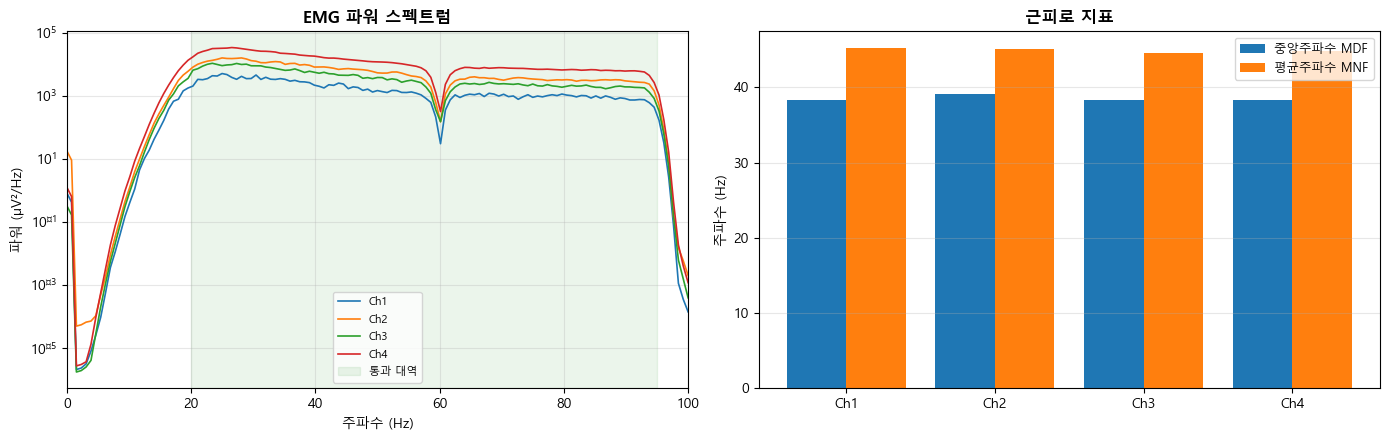

채널별 주파수 지표
----------------------------------------------------
채널            MDF (Hz)      MNF (Hz)
----------------------------------------------------
Ch1                38.3          45.2
Ch2                39.1          45.1
Ch3                38.3          44.5
Ch4                38.3          44.9
----------------------------------------------------

같은 근육을 반복 측정하며 이 값이 내려가면 피로가 쌓였다는 뜻입니다.
(이 보드는 100 Hz 까지만 보므로 절대값은 실제보다 낮게 나옵니다)


In [13]:
nperseg = min(256, filtered.shape[1])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# ---------- 왼쪽: 파워 스펙트럼 ----------
for i in range(N_CH):
    f, pxx = sp_signal.welch(filtered[i], fs=FS, nperseg=nperseg)
    axes[0].semilogy(f, pxx, linewidth=1.2, label=f'Ch{i+1}')

axes[0].axvspan(LOW, HIGH, color='green', alpha=0.08, label='통과 대역')
axes[0].set_xlabel('주파수 (Hz)')
axes[0].set_ylabel('파워 (µV²/Hz)')
axes[0].set_title('EMG 파워 스펙트럼', fontweight='bold')
axes[0].set_xlim(0, NYQUIST)
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3, which='both')

# ---------- 오른쪽: 중앙/평균 주파수 ----------
mdf_list, mnf_list = [], []
for i in range(N_CH):
    f, pxx = sp_signal.welch(filtered[i], fs=FS, nperseg=nperseg)
    m = (f >= LOW) & (f <= HIGH)          # 통과 대역 안에서만 계산
    fb, pb = f[m], pxx[m]
    df_f = fb[1] - fb[0]

    cum   = np.cumsum(pb) * df_f          # 누적 파워
    total = cum[-1]
    mdf = fb[np.searchsorted(cum, total / 2)] if total > 0 else 0.0   # 중앙주파수
    mnf = float(np.sum(fb * pb) * df_f / total) if total > 0 else 0.0 # 평균주파수
    mdf_list.append(mdf)
    mnf_list.append(mnf)

x = np.arange(N_CH)
axes[1].bar(x - 0.2, mdf_list, width=0.4, label='중앙주파수 MDF')
axes[1].bar(x + 0.2, mnf_list, width=0.4, label='평균주파수 MNF')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'Ch{i+1}' for i in range(N_CH)])
axes[1].set_ylabel('주파수 (Hz)')
axes[1].set_title('근피로 지표', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print('채널별 주파수 지표')
print('-' * 52)
print(f'{"채널":<8}{"MDF (Hz)":>14}{"MNF (Hz)":>14}')
print('-' * 52)
for i in range(N_CH):
    print(f'Ch{i+1:<7}{mdf_list[i]:>14.1f}{mnf_list[i]:>14.1f}')
print('-' * 52)
print()
print('같은 근육을 반복 측정하며 이 값이 내려가면 피로가 쌓였다는 뜻입니다.')
print(f'(이 보드는 {NYQUIST:.0f} Hz 까지만 보므로 절대값은 실제보다 낮게 나옵니다)')